#**Amazon Stock Price Predictor**
#*Proyecto Final de Data Science*
### Data Science 8CC2
### Universidad Autónoma de Chihuahua
### Facultad de Ingenieria
### Ingenieria en ciencias de la computación



### Docente: Olanda Prieto Ordaz
### Fecha de entrega: Jueves 27 de noviembre del 2025
> Allan Hall Solorio 358909

#**Introducción**

Para mi proyecto final de Data Science decídi utilizar la base de datos de Kaggle "Amazon Stock Price (All time)", ya que, desde pequeño me llamaba mucho la atención el tema de las Finanzas. Además de que, aspiro a trabajar cómo Analista de datos, en el sector Financiero, y el hacer este proyecto, me sirve para anexar a mi portafolio de Github donde subo todos mi proyectos relacionados al Análisis de datos (ML, Excel, Minitab, Python, Power BI etc.).

El objetivo del proyecto es desarrollar y comparar varios modelos de aprendizaje capaces de predecir el precio de cierre ajustado diario de las acciones de Amazon (Adj Close) utilizando variables históricas como apertura, máximo, mínimo, volumen y el comportamiento de días previos.

Esto con el fin de estimar la evolución futura del precio para identificar tendencias y evaluar la conveniencia de inversión.

A continuación se describe brevemente los pasos seguidos y todos los modelos que se implementaron.

1. **Obtención del dataset de Kaggle**
2. **Exploración inicial de los datos:** Análisis inicial para comprender la estructura de los datos, identificar posibles problemas (como valores faltantes o inconsistencias) y visualizar distribuciones de características clave.
3. **Partición de los datos en train y test:** División del dataset en conjuntos de entrenamiento y prueba para la evaluación del modelo.
4. **Preprocesamiento de los datos:**  Se realizaron las transformaciones necesarias sobre el dataset para preparar las variables antes del modelado, incluyendo el análisis de valores nulos, escalado numérico y generación de nuevas características (como variables rezagadas).
Posteriormente, se implementó un pipeline de preprocesamiento en la etapa final, aplicado únicamente al conjunto de entrenamiento, con el fin de estandarizar los datos y evitar fugas de información.
5. **Incorporación de Dependencia Temporal con Variables Rezagadas (Lags):** Introducción de valores pasados de las variables (lags) como nuevas características para capturar la dependencia temporal de los datos de series de tiempo.
6. **Reparticionar y reescalar el dataset mediante un Pipeline:** Una vez agregadas las variables rezagadas (lags), el DataFrame cambio (tiene más columnas y menos filas por los NaN iniciales). Por lo tanto es necesario volver a dividir y escalar los datos mediante un Pipeline sobre esta nueva versión (df_lagged) antes de entrenar los modelos.
7. **Implementación de los Modelos**
8. **Escalado de la Variable Objetivo para Modelos de Redes Neuronales:** Aplicación de StandardScaler a la variable objetivo ('Adj Close') para Redes Neuronales, crucial para estabilizar su entrenamiento y evitar errores de gradiente, a diferencia de modelos lineales o basados en árboles que son menos sensibles a la escala de 'y'.
9. **Identificación del mejor modelo:** Una vez implementados y evaluados en el conjunto de Prueba, se identifica y analiza el modelo que dio las mejores predicciones.
10. **Conclusión:** Se analizan los resultados obtenidos en esta practica, y se discuten posibles mejoras.
11. **Descarga del mejor modelo para implementarlo localmente usando la libreria Streamlit**
12. **Referencias**
---
# **Modelos Implementados**

## Modelos tradicionales de ML

1.   Regresion Lineal (Ridge)
2.   Random Forest
3.   SVR con kernel Lineal

## Modelos de Ensamble

4. Voting Regressor
5. AdaBoost (Adaptive Boosting)
6. GradientBoost
7. XGBoost (eXtreme Gradient Boosting)

## Modelos de Redes Neuronales (RNN)

8. MLP (MultiLayer Perceptron)
9. DNN (Deep Neural Network)
10. LSTM (Long Short Term Memory)



---



# 1º Obtención de los datos

In [1]:
# configuracion del kaggle
!pip install kaggle
!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [2]:
!kaggle datasets download -d kannan1314/amazon-stock-price-all-time -p /content/dataset --unzip

Dataset URL: https://www.kaggle.com/datasets/kannan1314/amazon-stock-price-all-time
License(s): CC0-1.0
  0% 0.00/117k [00:00<?, ?B/s]
100% 117k/117k [00:00<00:00, 338MB/s]


📊 Amazon Stock Price (All Time)
Este dataset contiene el histórico completo de los precios de la acción de Amazon (AMZN) desde su salida a bolsa hasta el 27/10/21. Incluye información financiera diaria con los siguientes campos principales:

Date → Fecha de la operación.

Open → Precio de apertura del día.

High → Precio máximo alcanzado.

Low → Precio mínimo alcanzado.

Close → Precio de cierre.

Adj Close → Precio de cierre ajustado (considera dividendos y splits).

Volume → Número de acciones transaccionadas ese día.



# 2º Exploración inicial de los datos

In [3]:
import pandas as pd
df = pd.read_csv('/content/dataset/Amazon.csv')
#df.head() muestra las primeras 5 filas del dataset
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,1997-05-15,2.437500,2.500000,1.927083,1.958333,1.958333,72156000
1,1997-05-16,1.968750,1.979167,1.708333,1.729167,1.729167,14700000
2,1997-05-19,1.760417,1.770833,1.625000,1.708333,1.708333,6106800
3,1997-05-20,1.729167,1.750000,1.635417,1.635417,1.635417,5467200
4,1997-05-21,1.635417,1.645833,1.375000,1.427083,1.427083,18853200
...,...,...,...,...,...,...,...
6150,2021-10-21,3414.250000,3440.280029,3403.000000,3435.010010,3435.010010,1881400
6151,2021-10-22,3421.000000,3429.840088,3331.300049,3335.550049,3335.550049,3133800
6152,2021-10-25,3335.000000,3347.800049,3297.699951,3320.370117,3320.370117,2226000
6153,2021-10-26,3349.510010,3416.120117,3343.979980,3376.070068,3376.070068,2693700


In [4]:
# obtener los tipos de datos de cada columna
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6155 entries, 0 to 6154
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       6155 non-null   object 
 1   Open       6155 non-null   float64
 2   High       6155 non-null   float64
 3   Low        6155 non-null   float64
 4   Close      6155 non-null   float64
 5   Adj Close  6155 non-null   float64
 6   Volume     6155 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 336.7+ KB


In [5]:
# obtener la sumatoria de datos nulos/faltantes en cada columna (si es que hay)
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


In [6]:
# obtener la sumatoria de duplicados
df.duplicated().sum()

np.int64(0)

In [7]:
# Para obtener media, desviación estandar, minímo, máximo, 25%, 50% y 75%
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,6155.000000,6155.000000,6155.000000,6155.000000,6155.000000,6.155000e+03
mean,520.556302,526.216132,514.277282,520.429832,520.429832,7.329010e+06
std,857.161696,865.821041,847.270905,856.668492,856.668492,7.149521e+06
min,1.406250,1.447917,1.312500,1.395833,1.395833,4.872000e+05
25%,38.750000,39.514999,38.104999,38.821251,38.821251,3.579350e+06
50%,92.669998,94.190002,90.750000,92.639999,92.639999,5.470000e+06
75%,528.949982,535.304993,521.950012,529.450012,529.450012,8.294950e+06
max,3744.000000,3773.080078,3696.790039,3731.409912,3731.409912,1.043292e+08


Con describe() podemos ver:

¿Qué tan volátil ha sido Amazon?

¿Cómo se comporta el volumen frente al precio?

# Evolución del precio de cierre  en el tiempo

Qué muestra: la tendencia histórica del precio de la acción

Por qué es útil: te da la visión general de cómo ha evolucionado Amazon a lo largo de los años. Sirve como punto de partida para predicciones.

Interpretación: puedes ver tendencias alcistas, bajistas y periodos de volatilidad

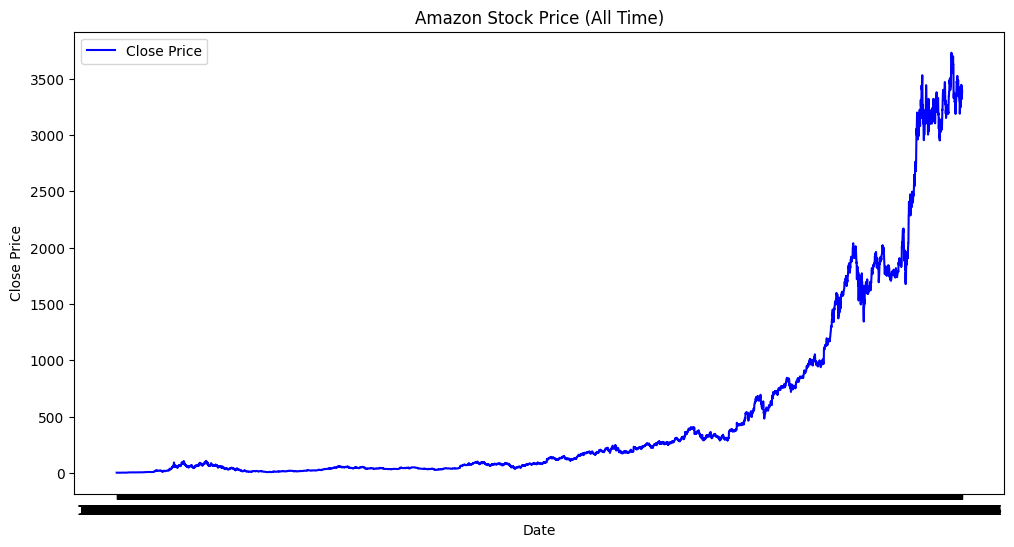

In [8]:
# Graficos
# Gráfico de líneas de Close a lo largo del tiempo
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Close'], label='Close Price', color='blue')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('Amazon Stock Price (All Time)')
plt.legend()
plt.show()

# Gráfico OHLC (Open, High, Low, Close)

Qué muestra: el movimiento diario del precio de apertura, cierre, máximo y mínimo.

Por qué es útil: es un estándar en finanzas para analizar patrones de trading. Permite ver si el mercado estuvo “alcista” o “bajista” en un día.

Interpretación: útil para análisis técnico (verde = subida, rojo = caída).

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 3.4 MB/s eta 0:00:00


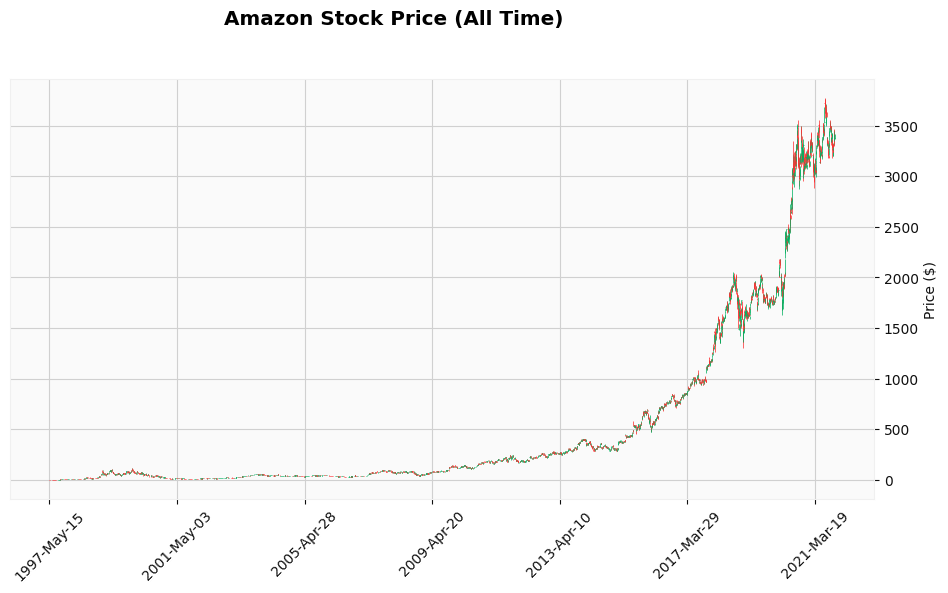

In [9]:
!pip install mplfinance
import mplfinance as mpf
# volver a cargar los datos, para poder realizar el grafico OHLC
df = pd.read_csv('/content/dataset/Amazon.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')

# Generar el grafico OHLC
mpf.plot(df, type='ohlc', style='yahoo', title='Amazon Stock Price (All Time)',
         ylabel= 'Price ($)',  figsize=(12, 6), warn_too_much_data=10000)

# resetear el indice para hacer date una columna, esto para no realizar transformaciones
df = df.reset_index()

# Histogramas de precios (Close)

Qué muestra: la distribución de los precios en todo el histórico.

Por qué es útil: permite ver si los precios siguen una distribución sesgada (por ejemplo, mayoría de precios bajos en los primeros años y muy altos en los últimos).

Interpretación: ayuda a decidir transformaciones (ej. logaritmo para normalizar)

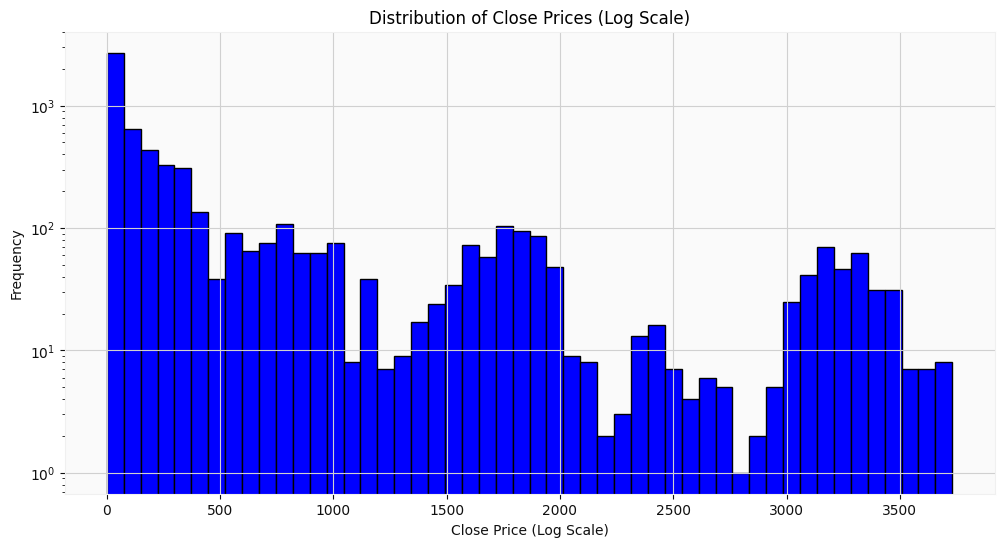

In [10]:
# histrograma de "Close" para checar distribucion de precios
plt.figure(figsize=(12, 6))
plt.hist(df['Close'], bins=50, color='blue', edgecolor='black', log=True) # Se agrego log scale y mayor bins para que se aprecie mejor el grafico
plt.xlabel('Close Price (Log Scale)')
plt.ylabel('Frequency')
plt.title('Distribution of Close Prices (Log Scale)')
plt.show()

# Volumen de transacciones a lo largo del tiempo

Qué muestra: la cantidad de acciones negociadas por día.

Por qué es útil: permite identificar momentos de alta actividad (ej. resultados trimestrales, noticias, crisis).

Interpretación: un incremento en volumen junto con cambios fuertes en precio puede señalar periodos críticos de trading.

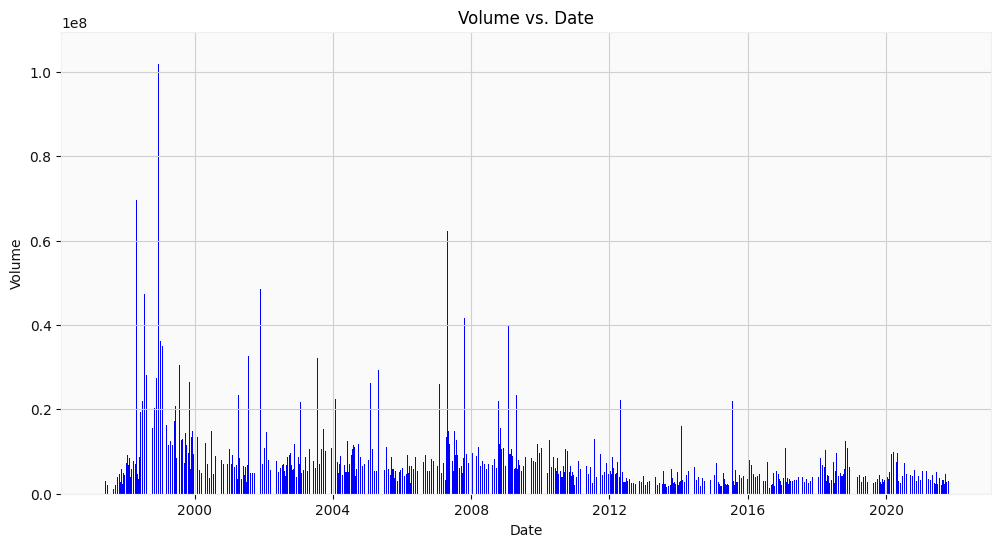

In [11]:
# grafico de barras de volume vs data
df = df.reset_index() # Resetting the index to make 'Date' a column again
plt.figure(figsize=(12, 6))
plt.bar(df['Date'], df['Volume'], color='blue')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.title('Volume vs. Date')
plt.show()

In [12]:
# correlacion de los datos
correlation_matrix = df.corr(numeric_only=True)
display(correlation_matrix)

,index,Open,High,Low,Close,Adj Close,Volume
index,1.000000,0.750286,0.750022,0.750662,0.750457,0.750457,-0.412464
Open,0.750286,1.000000,0.999934,0.999912,0.999842,0.999842,-0.240087
High,0.750022,0.999934,1.000000,0.999893,0.999924,0.999924,-0.238907
Low,0.750662,0.999912,0.999893,1.000000,0.999928,0.999928,-0.241351
Close,0.750457,0.999842,0.999924,0.999928,1.000000,1.000000,-0.240122
Adj Close,0.750457,0.999842,0.999924,0.999928,1.000000,1.000000,-0.240122
Volume,-0.412464,-0.240087,-0.238907,-0.241351,-0.240122,-0.240122,1.000000


# Matriz de correlación (Close, Open, High, Low, Volume, Adj Close)

Qué muestra: qué tan relacionadas están las variables.

Por qué es útil: por ejemplo, Close y Adj Close suelen estar altamente correlacionados; volumen puede no estar tan relacionado con precios.

Interpretación: sirve para decidir qué variables usar en un modelo predictivo y cuáles descartar por redundancia.

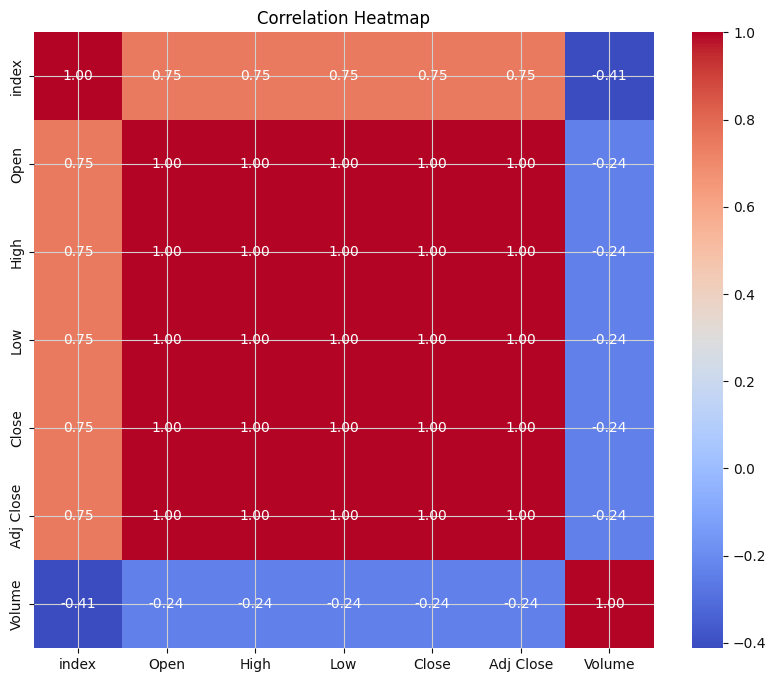

In [13]:
# visualizar dicha matriz
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

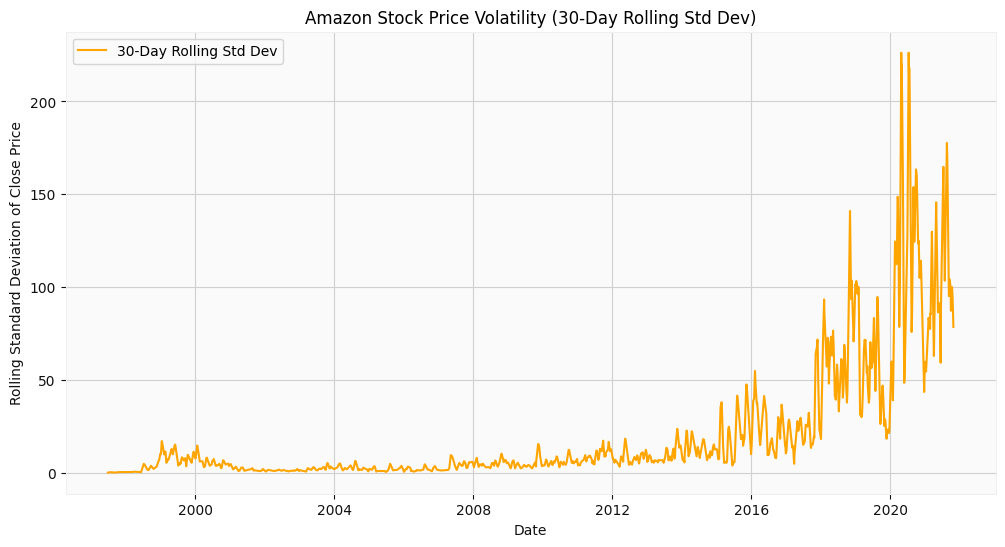

In [14]:
# Calcular y graficar la desviación estándar móvil (volatilidad)
df['Rolling_Std_Close'] = df['Close'].rolling(window=30).std() # Ventana de 30 días

plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Rolling_Std_Close'], label='30-Day Rolling Std Dev', color='orange')
plt.xlabel('Date')
plt.ylabel('Rolling Standard Deviation of Close Price')
plt.title('Amazon Stock Price Volatility (30-Day Rolling Std Dev)')
plt.legend()
plt.show()

*  Este gráfico ilustra la volatilidad histórica del precio de las acciones a lo largo del tiempo. La desviación estándar es una medida estadística de dispersión; por lo tanto, un valor más alto indica que el precio de las acciones ha fluctuado de forma más significativa dentro de ese período de 30 días, mientras que un valor más bajo sugiere una fluctuación menor.

* Información obtenida: A partir de este gráfico, se pueden identificar los períodos en los que las acciones de Amazon fueron más o menos volátiles. Los picos en el gráfico indican períodos de alta volatilidad (mayores oscilaciones de precios) y los valles indican períodos de menor volatilidad (precios más estables).

* Interpretación: Comprender la volatilidad es crucial en finanzas. Una alta volatilidad puede significar una mayor rentabilidad potencial, pero también un mayor riesgo. Una baja volatilidad sugiere un movimiento de precios más predecible, pero una rentabilidad potencialmente menor. Esta información puede ser útil para la gestión de riesgos y para elegir estrategias de trading adecuadas. Por ejemplo, durante períodos de alta volatilidad, los operadores intradía podrían encontrar más oportunidades, mientras que los inversores a largo plazo podrían preferir períodos de menor volatilidad.

Se puede ver cómo ha cambiado la volatilidad a lo largo del historial de las acciones de Amazon, probablemente mostrando aumentos durante eventos importantes del mercado o anuncios de la empresa.
    

# 3º Partición del dataset en train y test

En esta etapa se realizó la partición del conjunto de datos en dos subconjuntos: entrenamiento (80%) y prueba (20%), manteniendo el orden cronológico de los registros.

Dado que se trata de una serie temporal de precios históricos (acciones de Amazon), no se aplicó una partición estratificada, ya que este tipo de división es apropiada únicamente para problemas de clasificación, donde se busca preservar la proporción de clases entre los conjuntos.

En cambio, en este caso, el objetivo es predecir un valor continuo (precio de cierre ajustado) y, además, es fundamental mantener la secuencia temporal para evitar el uso de información futura durante el entrenamiento del modelo.
Por ello, se optó por una división cronológica simple, utilizando los primeros registros para el conjunto de entrenamiento y los más recientes para el conjunto de prueba.

In [15]:
# Asegurarse de que el dataset este ordenado cronologicamente
df = df.sort_values('Date').reset_index(drop=True)

In [16]:
from sklearn.model_selection import train_test_split

# Definir el target variable y las features
target = 'Adj Close'
features = ['Open', 'High', 'Low', 'Close', 'Volume']

X = df[features]
y = df[target]

# Particionar los datos cronologicamente
train_size = int(len(df) * 0.8)
X_train, X_test = X[0:train_size], X[train_size:len(df)]
y_train, y_test = y[0:train_size], y[train_size:len(df)]

print("Training set shape (X_train, y_train):", X_train.shape, y_train.shape)
print("Testing set shape (X_test, y_test):", X_test.shape, y_test.shape)

Training set shape (X_train, y_train): (4924, 5) (4924,)
Testing set shape (X_test, y_test): (1231, 5) (1231,)


In [17]:
# Verificar que la partición se hizo cronologicamente
print("Entrenamiento hasta:", df['Date'].iloc[train_size - 1])
print("Prueba desde:", df['Date'].iloc[train_size])

Entrenamiento hasta: 2016-12-06 00:00:00
Prueba desde: 2016-12-07 00:00:00


Estadísticas descriptivas para 'Adj Close' en el conjunto de entrenamiento:


,Adj Close
count,4924.000000
mean,146.063962
std,178.809080
min,1.395833
25%,34.893752
50%,65.875000
75%,210.822494
max,844.359985



Estadísticas descriptivas para 'Adj Close' en el conjunto de prueba:


,Adj Close
count,1231.000000
mean,2017.893313
std,859.387830
min,749.869995
25%,1442.169983
50%,1808.000000
75%,3053.619995
max,3731.409912


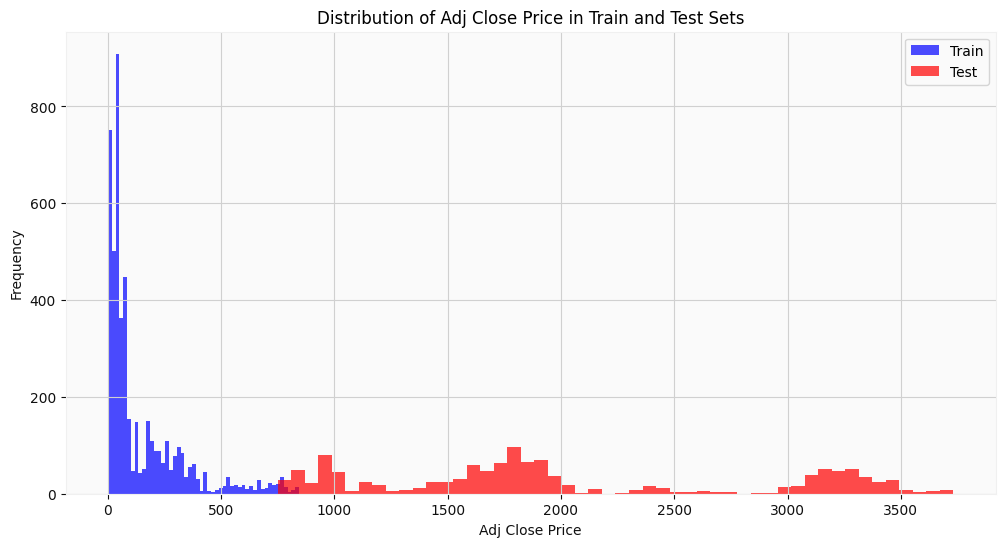

In [18]:
# Validar que las particiones de Train/Test tengan la misma distribución
# Para validar la distribución, podemos comparar las estadísticas descriptivas de la variable objetivo ('Adj Close')
# en ambos conjuntos.

print("Estadísticas descriptivas para 'Adj Close' en el conjunto de entrenamiento:")
display(y_train.describe())

print("\nEstadísticas descriptivas para 'Adj Close' en el conjunto de prueba:")
display(y_test.describe())

# Opcional: Visualizar la distribución de 'Adj Close' en ambos conjuntos usando histogramas
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.hist(y_train, bins=50, alpha=0.7, label='Train', color='blue')
plt.hist(y_test, bins=50, alpha=0.7, label='Test', color='red')
plt.xlabel('Adj Close Price')
plt.ylabel('Frequency')
plt.title('Distribution of Adj Close Price in Train and Test Sets')
plt.legend()
plt.show()

### Análisis de la Distribución de 'Adj Close' en los Conjuntos de Entrenamiento y Prueba

Tras dividir el dataset cronológicamente en conjuntos de entrenamiento (80%) y prueba (20%), hemos observado que la distribución de la variable objetivo 'Adj Close' (Precio de Cierre Ajustado) difiere significativamente entre ambos conjuntos.

**Observaciones de las Estadísticas Descriptivas:**

Al comparar las estadísticas descriptivas para 'Adj Close':

* **Conjunto de Entrenamiento:** La media y la mediana son considerablemente más bajas. El rango de valores (min a max) es más amplio en términos de la base de precios bajos, pero el valor máximo es mucho menor que en el conjunto de prueba. Esto refleja que el conjunto de entrenamiento contiene los datos históricos más antiguos, donde el precio de la acción de Amazon era significativamente más bajo.
* **Conjunto de Prueba:** La media y la mediana son mucho más altas. El valor mínimo en el conjunto de prueba es incluso mayor que el valor máximo en el conjunto de entrenamiento. Esto indica claramente que el conjunto de prueba abarca un período de tiempo más reciente, donde el precio de la acción ha experimentado un crecimiento sustancial.

**Observaciones del Histograma:**

El histograma visualiza esta diferencia de distribución de manera muy clara:

* El histograma del conjunto de entrenamiento muestra que la mayoría de los precios de cierre ajustados se concentran en rangos de valores más bajos, con una cola que se extiende hacia precios más altos a medida que avanza el tiempo dentro de ese conjunto.
* El histograma del conjunto de prueba, en cambio, muestra una distribución completamente desplazada hacia rangos de precios mucho más altos. La superposición entre los dos histogramas es mínima, lo que subraya la marcada diferencia en los niveles de precios entre los períodos de entrenamiento y prueba.

**Justificación de la Diferencia:**

Esta diferencia en la distribución es una característica esperable y natural de las series de tiempo financieras, especialmente para acciones como Amazon que han tenido un crecimiento significativo a lo largo de su historia. La partición cronológica (usando datos más antiguos para entrenar y datos más recientes para probar) inherentemente separa períodos con diferentes rangos de precios debido a la tendencia alcista a largo plazo.

En un contexto de predicción de series de tiempo, nuestro objetivo es que el modelo aprenda los patrones y la dinámica del precio basándose en el historial (conjunto de entrenamiento) para poder predecir valores futuros (conjunto de prueba), incluso si esos valores futuros están en un rango de precios diferente. Aunque la distribución difiere, el escalado de las características (realizado posteriormente) ayudará a los modelos a manejar las diferencias de magnitud. La clave para una buena predicción en este escenario será la capacidad del modelo para capturar las relaciones entre las características y la variable objetivo que se mantienen consistentes a lo largo del tiempo, a pesar del cambio en el nivel general de precios.

Modelos que pueden manejar tendencias o que utilizan características que capturan la relación proporcional entre los precios (como retornos o cambios porcentuales, aunque no se hayan usado aquí) o que incluyen lags efectivos serán más adecuados.

# 4º Preprocesamiento de los datos

El preprocesamiento de los datos es un paso crucial antes de entrenar modelos de Machine Learning, especialmente cuando se trabaja con datos financieros como los precios de las acciones. Las variables de este dataset, como `Open`, `High`, `Low`, `Close`, y `Volume`, tienen escalas muy diferentes. Por ejemplo, el volumen de transacciones puede ser significativamente mayor que los precios de las acciones.

En esta etapa inicial se realiza una revisión y limpieza del conjunto de datos, identificando valores nulos, analizando distribuciones y preparando las variables que posteriormente servirán para generar nuevas características (como las variables rezagadas).  

El **pipeline de transformación** no se aplica todavía en esta fase, ya que el dataset será **reparticionado** y **reescalado** más adelante, después de incorporar la dependencia temporal mediante las variables *lag*.  
De esta forma, el pipeline se ajusta únicamente sobre el conjunto de entrenamiento final, cumpliendo con las buenas prácticas de modelado en series temporales y evitando fugas de información del futuro hacia el pasado.

**¿Por qué escalar los datos?**

Cuando utilizamos modelos de regresión lineal, máquinas de vectores de soporte (SVM), o incluso redes neuronales para predecir un valor numérico continuo como el precio de cierre ajustado (`Adj Close`), estos modelos pueden verse afectados por la diferencia de escalas entre las características. Sin escalado, el modelo podría asignar una importancia desproporcionada a las características con valores más grandes (como `Volume`), lo que podría llevar a un rendimiento subóptimo.

**¿Por qué StandardScaler?**

Existen varias técnicas de escalado, pero `StandardScaler` es una opción adecuada para este tipo de datos y modelos. `StandardScaler` transforma los datos de tal manera que cada característica tiene una media de 0 y una desviación estándar de 1. Esto se logra restando la media de cada característica y dividiendo por su desviación estándar.

Esta transformación es particularmente beneficiosa para modelos que dependen de la distancia entre puntos de datos o de los coeficientes de las características:

*   **Regresión lineal:** Ayuda a que los coeficientes del modelo no se vean influenciados por la escala de las características.
*   **SVM:** La distancia euclidiana, que es fundamental en SVM, tiene más sentido cuando las características están en la misma escala.
*   **Redes neuronales:** Los modelos de redes neuronales a menudo convergen más rápido cuando los datos de entrada están centrados alrededor de cero.

Aunque modelos basados en árboles como Decision Tree y Random Forest no requieren escalado para funcionar correctamente, entrenarlos con datos escalados no perjudica su rendimiento y permite utilizar el mismo pipeline de preprocesamiento para diferentes tipos de modelos.

**¿Qué se obtiene al escalar los datos?**

Al aplicar `StandardScaler`, obtenemos conjuntos de datos de entrenamiento (`X_train_scaled`) y prueba (`X_test_scaled`) donde las características numéricas están transformadas a una escala común. Esto asegura que ninguna característica domine a las otras debido a su magnitud, permitiendo que los algoritmos de Machine Learning aprendan de manera más efectiva las relaciones subyacentes en los datos y realicen predicciones más precisas del precio de cierre ajustado.

In [19]:
from sklearn.preprocessing import StandardScaler

# Inicializar el StandardScaler
scaler = StandardScaler()

# Ajustar el scaler solo en los datos de entrenamiento y transformar ambos conjuntos
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (4924, 5)
X_test_scaled shape: (1231, 5)


In [20]:
# Mostrar las primeras filas despues del preprocesamiento
df_scaled = pd.DataFrame(X_train_scaled, columns=features)
df_scaled.head()

,Open,High,Low,Close,Volume
0,-0.802915,-0.806927,-0.802013,-0.806001,8.275908
1,-0.805536,-0.809816,-0.803248,-0.807283,0.853983
2,-0.806701,-0.810972,-0.803718,-0.807399,-0.256051
3,-0.806875,-0.811087,-0.803659,-0.807807,-0.338672
4,-0.807399,-0.811665,-0.805129,-0.808972,1.390476


In [21]:
# Mostrar con describe() los datos preprocesados
df_scaled.describe()

,Open,High,Low,Close,Volume
count,4924.000000,4.924000e+03,4.924000e+03,4.924000e+03,4.924000e+03
mean,0.000000,9.235324e-17,-4.617662e-17,9.235324e-17,-6.926493e-17
std,1.000102,1.000102e+00,1.000102e+00,1.000102e+00,1.000102e+00
min,-0.808681,-8.127628e-01,-8.054823e-01,-8.091469e-01,-9.819673e-01
25%,-0.621901,-6.243917e-01,-6.200286e-01,-6.217889e-01,-5.204900e-01
50%,-0.448039,-4.443242e-01,-4.547574e-01,-4.485069e-01,-2.586022e-01
75%,0.350710,3.653693e-01,3.530533e-01,3.622026e-01,1.327521e-01
max,3.912750,3.878266e+00,3.932692e+00,3.905657e+00,1.243191e+01


# 5º Incorporación de Dependencia Temporal con Variables Rezagadas (Lags)

**¿Qué son las variables rezagadas (lags) y por qué son importantes para series de tiempo?**

En el análisis de series de tiempo, como los precios de las acciones, el valor actual de una variable (por ejemplo, el precio de cierre de hoy) a menudo depende de sus valores pasados. Los modelos de Machine Learning tradicionales (como la Regresión Lineal, Random Forest o SVM) no tienen una noción inherente de tiempo o secuencia; tratan cada fila de datos como un punto de datos independiente.

Para que estos modelos puedan capturar la dependencia temporal, necesitamos explícitamente agregar información del pasado al conjunto de características de cada fila. Aquí es donde entran las variables rezagadas. Una variable rezagada para una característica dada es simplemente el valor de esa característica en un punto de tiempo anterior.

Por ejemplo, si queremos predecir el precio de cierre de mañana, podríamos usar como características no solo el precio de apertura, máximo, mínimo, cierre y volumen de hoy, sino también el precio de cierre de ayer, de anteayer, etc. Estos valores pasados son las variables rezagadas.

**¿Cómo ayudan las variables rezagadas a los modelos a "ver" el contexto temporal?**

Al incluir variables rezagadas, transformamos un problema de serie de tiempo en un problema de regresión supervisada donde las características de entrada (X) incluyen los valores de hoy y de días anteriores, y la variable objetivo (y) es el valor que queremos predecir (por ejemplo, el precio de cierre de mañana).

De esta manera, el modelo puede aprender relaciones como: "si el precio de cierre subió en los últimos 3 días y el volumen aumentó, es probable que vuelva a subir mañana". Sin los lags, el modelo solo vería el estado del día actual y no podría identificar estos patrones basados en la historia reciente.

##Implementación de variables rezagadas

Para implementar esto, crearemos nuevas columnas en nuestro DataFrame. Cada nueva columna representará el valor de una característica original desplazada en el tiempo. Podemos elegir qué características rezagar y cuántos períodos de rezago incluir. Para la predicción del precio de cierre ajustado, tiene sentido rezagar el Adj Close mismo, así como quizás otras variables relevantes como Volume.

Considerando que queremos predecir el Adj Close del siguiente día, el objetivo (y) ya representa ese valor futuro en la forma en que dividimos los datos. Ahora, necesitamos asegurarnos de que las características (X) para un día dado incluyan la información del día actual y de los días anteriores para predecir ese futuro valor de Adj Close.

El enfoque común es usar los datos del día t (Open, High, Low, Close, Volume) y potencialmente lags de días anteriores (t-1, t-2, etc.) para predecir el Adj Close del día t+1. Sin embargo, dado que nuestra variable objetivo y ya está alineada para predecir el Adj Close del siguiente día (debido a la partición cronológica donde X llega hasta el día n-1 y y es el Adj Close del día n), podemos simplemente usar las características de X (Open, High, Low, Close, Volume del día actual) para predecir el Adj Close del día siguiente.

Si quisiéramos usar lags (por ejemplo, Open, High, Low, Close, Volume del día t Y Close del día t-1, Close del día t-2, etc.) para predecir el Adj Close del día t+1, necesitaríamos reestructurar ligeramente el conjunto de datos antes de dividirlo en entrenamiento y prueba.


## Ajuste y manejo del índice del DataFrame

Al generar las variables rezagadas mediante la función shift() y eliminar las primeras filas con valores NaN usando df.dropna(), se crea un nuevo DataFrame denominado df_lagged.
Este proceso conserva el índice original del DataFrame base (df), por lo que el nuevo conjunto mantiene las fechas o posiciones originales, pero con una secuencia numérica discontinua (debido a las filas eliminadas).

Sin embargo, este índice no afecta en absoluto el entrenamiento ni la predicción de los modelos, ya que las particiones de los datos (X_train, X_test, y_train, y_test) se realizan por posición (usando iloc o slicing [:train_size]), y no en función del índice.
Es decir, el índice solo se conserva como referencia temporal para visualizaciones y control de orden, pero no participa como variable predictora ni influye en los cálculos del modelo.

Se opto por eliminarlo, ya que, aunque no afecte para nada el entrenamiento, puede llegar a confundir y además es considerado cómo buena practica, el eliminar las columnas innecesarias, durante el preprocesamiento de los datos.

In [22]:
import pandas as pd
# Agregar variables rezagadas (lags) para 'Adj Close'
# Shift(1) significa rezagar por 1 día (usar el valor de ayer para la fila de hoy)
df['Adj Close_Lag1'] = df['Adj Close'].shift(1)
df['Adj Close_Lag2'] = df['Adj Close'].shift(2)
df['Adj Close_Lag3'] = df['Adj Close'].shift(3)

# Eliminar las filas con valores NaN resultantes del shift (los primeros días no tendrán lags)
df_lagged = df.dropna()

# Eliminar columnas no necesarias para el modelado
# 'rolling_std_close' fue usada solo durante la exploración de datos
# para analizar la volatilidad de 30 días del precio ajustado.
# 'index' se genera automáticamente al resetear el índice y no aporta información al modelo.
cols_to_drop = [col for col in ['Rolling_Std_Close', 'index'] if col in df_lagged.columns]
if cols_to_drop:
    df_lagged = df_lagged.drop(columns=cols_to_drop)

# Reiniciar el índice para eliminar la discontinuidad generada por dropna().
# Esto no afecta el entrenamiento, ya que las divisiones se hacen por posición
df_lagged = df_lagged.reset_index(drop=True)

display(df_lagged.head())

,Date,Open,High,Low,Close,Adj Close,Volume,Adj Close_Lag1,Adj Close_Lag2,Adj Close_Lag3
0,1997-06-26,1.520833,1.520833,1.505208,1.510417,1.510417,3189600,1.510417,1.510417,1.500000
1,1997-06-27,1.515625,1.515625,1.479167,1.489583,1.489583,1188000,1.510417,1.510417,1.510417
2,1997-06-30,1.510417,1.598958,1.479167,1.541667,1.541667,2746800,1.489583,1.510417,1.510417
3,1997-07-01,1.541667,1.541667,1.510417,1.515625,1.515625,1292400,1.541667,1.489583,1.510417
4,1997-07-02,1.515625,1.593750,1.510417,1.588542,1.588542,3882000,1.515625,1.541667,1.489583


### Explicación de `shift()` para la creación de variables rezagadas (Lags)

El método `shift()` es una función que proviene de la librería **pandas**, la cual es una herramienta esencial para la manipulación y análisis de datos en Python. Cuando se aplica a una `Serie` o `DataFrame` de pandas, `shift()` desplaza los datos a lo largo de un eje (generalmente el índice de tiempo) por un número determinado de períodos. Esto es fundamental para crear **variables rezagadas (lags)**.

**¿Qué hace matemáticamente?**

Matemáticamente, aplicar `df['Columna'].shift(n)` significa que, para cada fila en la `Columna`, el valor de esa fila se reemplaza por el valor de la fila `n` posiciones *anteriores* en la misma columna. Si `n` es positivo, se desplaza hacia abajo (hacia el futuro), lo que efectivamente trae valores del pasado a la fila actual.

Por ejemplo:

*   `df['Adj Close'].shift(1)`: Para cada día `t`, esta nueva columna tendrá el valor de `'Adj Close'` del día `t-1` (ayer).
*   `df['Adj Close'].shift(2)`: Para cada día `t`, esta nueva columna tendrá el valor de `'Adj Close'` del día `t-2` (anteayer).
*   `df['Adj Close'].shift(3)`: Para cada día `t`, esta nueva columna tendrá el valor de `'Adj Close'` del día `t-3`.

**Ejemplo con un DataFrame simple:**

Original DataFrame:

| Date       | Value |
|:-----------|:------|
| 2023-01-01 | 10    |
| 2023-01-02 | 12    |
| 2023-01-03 | 11    |
| 2023-01-04 | 15    |

Después de `df['Value_Lag1'] = df['Value'].shift(1)`:

| Date       | Value | Value_Lag1 |
|:-----------|:------|:-----------|
| 2023-01-01 | 10    | NaN        |
| 2023-01-02 | 12    | 10         |
| 2023-01-03 | 11    | 12         |
| 2023-01-04 | 15    | 11         |

Como se puede observar, el primer valor de `Value_Lag1` es `NaN` (Not a Number) porque no hay un día anterior al 2023-01-01 del cual tomar un valor. En el código anterior, la línea `df_lagged = df.dropna()` se encarga precisamente de eliminar estas filas iniciales que contienen `NaN` debido al desplazamiento, asegurando que todos los registros tengan valores de lag válidos.

**¿Por qué es útil para los lags?**

En el contexto de la predicción de series de tiempo financieras, el precio de una acción hoy está altamente correlacionado con su precio ayer o días anteriores. Al crear estas variables rezagadas, transformamos un problema de predicción de series de tiempo en un problema de regresión supervisada, donde el modelo puede usar los precios pasados como características para predecir el precio futuro. De esta manera, el modelo de Machine Learning puede aprender la dependencia temporal inherente a los datos de precios de acciones.

Ahora que hemos agregado las variables rezagadas, necesitaremos volver a dividir el dataset (`df_lagged`) en conjuntos de entrenamiento y prueba, y luego aplicar el escalado a las nuevas características, incluyendo los lags.

# 6º Reparticionar y reescalar el dataset mediante un Pipeline

En esta sección se realiza la repartición cronológica (80/20) del conjunto de datos y la transformación de las variables predictoras utilizando un **Pipeline**.  
El Pipeline se ajusta únicamente con el conjunto de entrenamiento (`train`) e incluye las etapas de imputación de valores nulos y normalización de los datos numéricos mediante `StandardScaler`.

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Definir las columnas (features y target)
target = 'Adj Close'
features = ['Open', 'High', 'Low', 'Close', 'Volume',
            'Adj Close_Lag1', 'Adj Close_Lag2', 'Adj Close_Lag3']

X = df_lagged[features]
y = df_lagged[target]

# Mantener división temporal (80/20)
train_size = int(len(df_lagged) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Creación del Pipeline
# Este pipeline se entrena solo con TRAIN
preprocess_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),   # Rellenar valores nulos
    ('scaler', StandardScaler())                   # Normalizar variables
])

# Ajustar el pipeline SOLO con el set de entrenamiento
X_train_prep = preprocess_pipeline.fit_transform(X_train)

# Aplicar el pipeline al set de prueba sin volver a ajustar
X_test_prep = preprocess_pipeline.transform(X_test)

print("Transformación completada con el Pipeline")
print("X_train_prep shape:", X_train_prep.shape)
print("X_test_prep shape:", X_test_prep.shape)


Transformación completada con el Pipeline
X_train_prep shape: (4900, 8)
X_test_prep shape: (1226, 8)


# 7º Implementación de Modelos
#**Modelos tradicionales de ML**

##Implementación de un Modelo de Regresión Lineal

Dado que los modelos de Regresión Lineal estándar tienen pocos hiperparámetros para optimizar mediante técnicas de "tuneo" extensas como Grid Search o Random Search, se ha optado por implementar una variante más robusta y adecuada para problemas con datos correlacionados, como las series de tiempo financieras: la Regresión Ridge.

La Regresión Ridge introduce una penalización L2 a la función de costo de la Regresión Lineal. Esta penalización añade la suma de los cuadrados de los coeficientes del modelo multiplicada por un parámetro de regularización (alpha). Esto tiene el efecto de reducir la magnitud de los coeficientes, lo que ayuda a:

1.  **Reducir la varianza del modelo:** Al limitar el tamaño de los coeficientes, Ridge hace que el modelo sea menos sensible a pequeñas fluctuaciones en los datos de entrenamiento, mejorando su capacidad de generalizar a datos no vistos.
2.  **Manejar la multicolinealidad:** A diferencia de Lasso (que puede eliminar variables cuando hay alta correlación), Ridge reduce los coeficientes de las variables correlacionadas sin eliminarlas por completo. Esto es beneficioso en este caso, ya que variables como Open, High, Low y Close están intrínsecamente correlacionadas, y los lags de Adj Close también lo estarán. Ridge conserva la información útil de todas estas variables.
3.  **Mejorar la generalización:** Al reducir la varianza, Ridge tiende a ofrecer un mejor rendimiento predictivo en el conjunto de prueba, lo cual es crucial para la predicción de precios futuros.

Aunque Ridge tiene un hiperparámetro principal a tunear (`alpha`), su impacto es significativo en la regularización del modelo.

Mejores hiperparámetros: {'alpha': 0.001}
Mejor score de validación cruzada (Negated MSE): -0.00015617517604493364

Evaluación del Mejor Modelo de Regresión Ridge (tuneado):
Mean Absolute Error (MAE): 0.02887394816943064
Mean Squared Error (MSE): 0.0018610702009634092
Root Mean Squared Error (RMSE): 0.04314012286680938
R-squared (R2): 0.9999999974664202


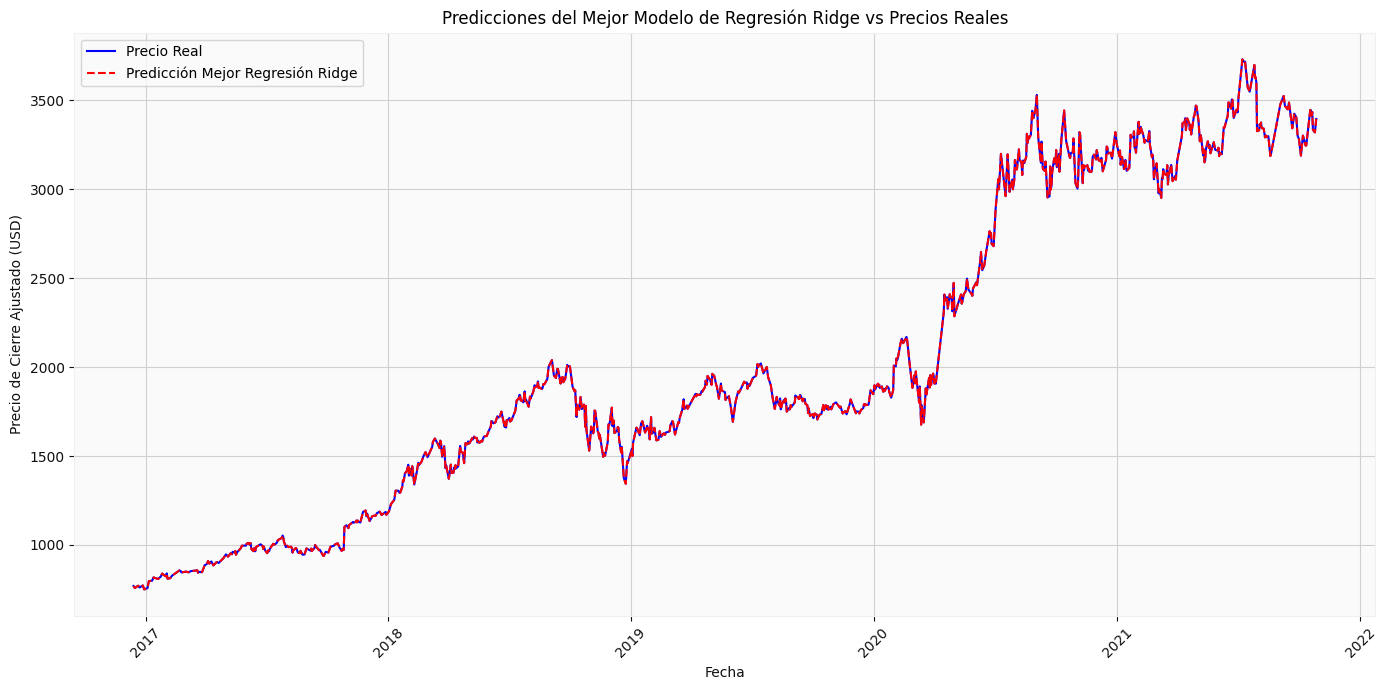

In [24]:
# Modelo de Regresión Ridge
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Definir el rango de valores de alpha
param_grid_ridge = {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}

# Inicializar el modelo Ridge
ridge = Ridge()

# Inicializar GridSearchCV
# Usaremos 'neg_mean_squared_error' como métrica de scoring, ya que GridSearchCV
# busca maximizar la métrica. El MSE negativo es equivalente a minimizar el MSE positivo.
# También se podría usar 'r2'.
grid_search_ridge = GridSearchCV(ridge, param_grid_ridge, cv=5, scoring='neg_mean_squared_error')

# Ajustar el objeto GridSearchCV a los datos de entrenamiento escalados
grid_search_ridge.fit(X_train_prep, y_train)

# Mostrar los mejores hiperparámetros encontrados y el mejor score
print("Mejores hiperparámetros:", grid_search_ridge.best_params_)
print("Mejor score de validación cruzada (Negated MSE):", grid_search_ridge.best_score_)

# Obtener el mejor modelo
best_ridge_model = grid_search_ridge.best_estimator_

# Realizar predicciones en el conjunto de prueba con el mejor modelo
y_pred_best_ridge = best_ridge_model.predict(X_test_prep)

# Evaluar el mejor modelo en el conjunto de prueba
mae_best_ridge = mean_absolute_error(y_test, y_pred_best_ridge)
mse_best_ridge = mean_squared_error(y_test, y_pred_best_ridge)
rmse_best_ridge = np.sqrt(mse_best_ridge) # Calcular RMSE tomando la raíz cuadrada del MSE
r2_best_ridge = r2_score(y_test, y_pred_best_ridge)

print("\nEvaluación del Mejor Modelo de Regresión Ridge (tuneado):")
print(f"Mean Absolute Error (MAE): {mae_best_ridge}")
print(f"Mean Squared Error (MSE): {mse_best_ridge}")
print(f"Root Mean Squared Error (RMSE): {rmse_best_ridge}")
print(f"R-squared (R2): {r2_best_ridge}")

# Visualizar las predicciones del mejor modelo vs los valores reales
# Obtener las fechas correspondientes al conjunto de prueba desde el DataFrame df_lagged
# Usamos el índice del conjunto de prueba (y_test) para seleccionar las fechas correctas
test_dates = df_lagged.loc[y_test.index, 'Date']


plt.figure(figsize=(14, 7))
plt.plot(test_dates, y_test, label='Precio Real', color='blue')
plt.plot(test_dates, y_pred_best_ridge, label='Predicción Mejor Regresión Ridge', color='red', linestyle='--')
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre Ajustado (USD)')
plt.title('Predicciones del Mejor Modelo de Regresión Ridge vs Precios Reales')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Tuneo de Hiperparámetros para Regresión Ridge con Grid Search

Aunque Regresión Ridge es un modelo relativamente simple con un solo hiperparámetro principal (`alpha`), encontrar el valor óptimo de `alpha` es crucial para equilibrar el ajuste del modelo con la regularización. Un `alpha` muy pequeño puede llevar a un sobreajuste (aunque menos probable que con Regresión Lineal simple), mientras que un `alpha` muy grande puede resultar en un subajuste.

Grid Search es una técnica sistemática para explorar un rango predefinido de valores para uno o más hiperparámetros. Para cada combinación de hiperparámetros en la "cuadrícula", se entrena y evalúa el modelo utilizando validación cruzada. El conjunto de hiperparámetros que produce el mejor rendimiento (según una métrica de evaluación específica, como R-squared o Mean Squared Error) se considera el óptimo.

En este caso, se uso Grid Search para encontrar el mejor valor de `alpha` para nuestro modelo de Regresión Ridge, entrenándolo en los datos escalados.

### Análisis e Interpretación de los Resultados del Modelo de Regresión Ridge Tuneado

Después de realizar el Grid Search para encontrar el mejor hiperparámetro `alpha` para el modelo de Regresión Ridge, obtuvimos los siguientes resultados:

*   **Mejores hiperparámetros:** `{'alpha': 0.001}`
    *   Interpretación: Este es el valor de `alpha` que minimizó el Error Cuadrático Medio Negativo durante la validación cruzada en el conjunto de entrenamiento. Un valor de `alpha` pequeño (`0.001`) sugiere que no se necesitó una penalización de regularización muy fuerte para este conjunto de datos y características (incluyendo los lags). Esto podría indicar que las características están bien comportadas o que la relación lineal subyacente es bastante fuerte.

*   **Mejor score de validación cruzada (Negated MSE):** `-0.00015617517604493364`
    *   Interpretación: Este es el valor promedio del Error Cuadrático Medio Negativo en los diferentes folds de validación cruzada con el `alpha` óptimo. Un valor muy cercano a cero (en negativo) indica que el modelo tuvo un rendimiento muy bueno en la predicción durante la validación cruzada.

Ahora, veamos las métricas de evaluación en el conjunto de **prueba**, que nos dan una indicación de qué tan bien generaliza el modelo a datos no vistos:

*   **Mean Absolute Error (MAE):** `0.02887` (aproximadamente)
    *   Interpretación: En promedio, la diferencia absoluta entre el precio de cierre ajustado real y el precio predicho por el modelo es de aproximadamente 0.02887 USD. Un MAE bajo indica que las predicciones del modelo están muy cerca de los valores reales.

*   **Mean Squared Error (MSE):** `0.00186` (aproximadamente)
    *   Interpretación: El MSE penaliza más los errores grandes que el MAE al elevar al cuadrado las diferencias. Un valor bajo de MSE también sugiere que el modelo tiene un buen rendimiento, con errores de predicción generalmente pequeños.

*   **Root Mean Squared Error (RMSE):** `0.04314` (aproximadamente)
    *   Interpretación: El RMSE está en la misma unidad que la variable objetivo (USD). Un RMSE de aproximadamente 0.04314 USD significa que la desviación estándar de los residuos (la diferencia entre los valores predichos y observados) es de alrededor de 0.04314 USD. Al igual que el MAE y el MSE, un valor bajo de RMSE indica predicciones precisas.

*   **R-squared (R2):** `0.9999999974664202` (aproximadamente)
    *   Interpretación: El R-squared representa la proporción de la varianza en la variable objetivo (`Adj Close`) que es predecible a partir de las características (`X`). Un valor de R2 extremadamente cercano a 1 (¡casi perfecto!) indica que el modelo explica casi toda la varianza en los precios de cierre ajustados del conjunto de prueba. Esto sugiere que las características utilizadas (incluyendo los lags) son muy predictivas del precio del día siguiente.

**Interpretación del Gráfico:**

El gráfico muestra la comparación entre los precios de cierre ajustados reales (línea azul) y las predicciones del modelo de Regresión Ridge (línea roja discontinua) en el conjunto de prueba.

*   Visualmente, la línea roja de predicción sigue muy de cerca la línea azul de precios reales. Esto confirma las métricas de evaluación, indicando que el modelo es capaz de predecir con gran precisión el precio de cierre ajustado del siguiente día basándose en los datos históricos y los lags.
*   Es notable lo bien que el modelo captura la tendencia general y las fluctuaciones diarias en el precio de las acciones.


Basado en estas métricas y la visualización, el modelo de Regresión Ridge con el `alpha` tuneado (`0.001`) ha demostrado un rendimiento excepcionalmente alto en la predicción del precio de cierre ajustado en el conjunto de prueba. Las métricas son muy favorables (MAE, MSE, RMSE bajos y R2 muy alto), lo que sugiere que el modelo ha aprendido efectivamente los patrones en los datos históricos, incluyendo la dependencia temporal introducida por los lags.

Este es un excelente resultado para un modelo lineal, lo que subraya la fuerte relación lineal entre las características y la variable objetivo en este conjunto de datos particular de precios de acciones, especialmente cuando se incluyen lags.

## Implementación de un Modelo de Random Forest

Iniciando Grid Search para Random Forest...
Fitting 3 folds for each of 36 candidates, totalling 108 fits
Grid Search para Random Forest finalizado.

Mejores hiperparámetros para Random Forest: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 150}
Mejor score de validación cruzada (Negated MSE) para Random Forest: -24870.224388465267

Evaluación del Mejor Modelo de Random Forest (tuneado):
Mean Absolute Error (MAE): 1182.4950015904997
Mean Squared Error (MSE): 2129193.469926457
Root Mean Squared Error (RMSE): 1459.175613120798
R-squared (R2): -1.8985911345635587


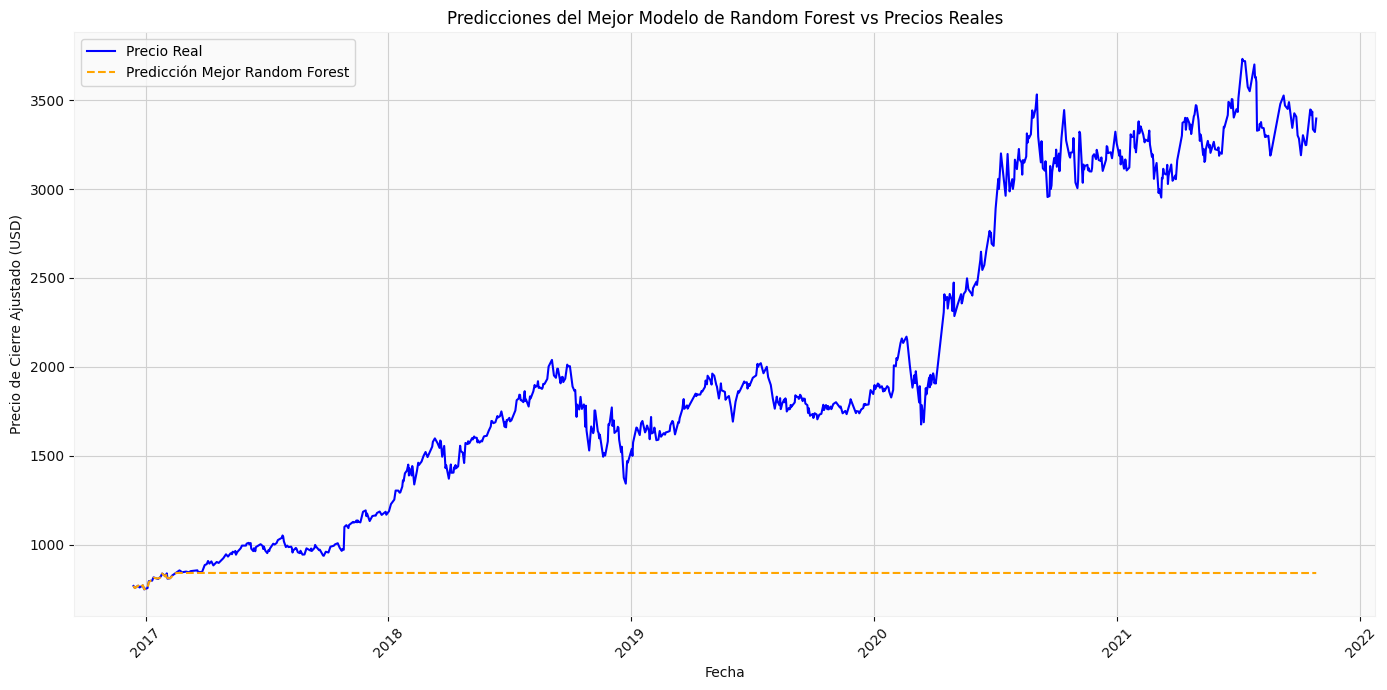

In [25]:
# Implementación de un Modelo de Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Definir el rango de hiperparámetros para Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 150], # Número de árboles en el bosque
    'max_depth': [10, 20, None],      # Profundidad máxima de los árboles
    'min_samples_split': [2, 5],      # Número mínimo de muestras para dividir un nodo
    'min_samples_leaf': [1, 2]        # Número mínimo de muestras en un nodo hoja
}

# Inicializar el modelo Random Forest Regressor
rf = RandomForestRegressor(random_state=42, n_jobs=-1) # n_jobs=-1 para usar todos los cores

# Inicializar GridSearchCV
# Usaremos 'neg_mean_squared_error' como métrica de scoring.
grid_search_rf = GridSearchCV(rf, param_grid_rf, cv=3, scoring='neg_mean_squared_error', n_jobs=-1, verbose=2) # cv=3 para reducir el tiempo, verbose para ver el progreso

# Ajustar el objeto GridSearchCV a los datos de entrenamiento escalados
print("Iniciando Grid Search para Random Forest...")
grid_search_rf.fit(X_train_prep, y_train)
print("Grid Search para Random Forest finalizado.")


# Mostrar los mejores hiperparámetros encontrados y el mejor score
print("\nMejores hiperparámetros para Random Forest:", grid_search_rf.best_params_)
print("Mejor score de validación cruzada (Negated MSE) para Random Forest:", grid_search_rf.best_score_)

# Obtener el mejor modelo
best_rf_model = grid_search_rf.best_estimator_

# Realizar predicciones en el conjunto de prueba con el mejor modelo
y_pred_best_rf = best_rf_model.predict(X_test_prep)

# Evaluar el mejor modelo en el conjunto de prueba
mae_best_rf = mean_absolute_error(y_test, y_pred_best_rf)
mse_best_rf = mean_squared_error(y_test, y_pred_best_rf)
rmse_best_rf = np.sqrt(mse_best_rf)
r2_best_rf = r2_score(y_test, y_pred_best_rf)

print("\nEvaluación del Mejor Modelo de Random Forest (tuneado):")
print(f"Mean Absolute Error (MAE): {mae_best_rf}")
print(f"Mean Squared Error (MSE): {mse_best_rf}")
print(f"Root Mean Squared Error (RMSE): {rmse_best_rf}")
print(f"R-squared (R2): {r2_best_rf}")

# Visualizar las predicciones del mejor modelo vs los valores reales
# Obtener las fechas correspondientes al conjunto de prueba
test_dates = df_lagged.loc[y_test.index, 'Date']

plt.figure(figsize=(14, 7))
plt.plot(test_dates, y_test, label='Precio Real', color='blue')
plt.plot(test_dates, y_pred_best_rf, label='Predicción Mejor Random Forest', color='orange', linestyle='--')
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre Ajustado (USD)')
plt.title('Predicciones del Mejor Modelo de Random Forest vs Precios Reales')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Análisis e Interpretación de los Resultados del Modelo de Random Forest Tuneado

Después de realizar el Grid Search para encontrar los mejores hiperparámetros para el modelo de Random Forest, obtuvimos los siguientes resultados:

*   **Mejores hiperparámetros para Random Forest:** `{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 150}`
    *   **Interpretación:**
        *   `n_estimators: 150`: Indica que el mejor modelo utiliza 150 árboles de decisión en el bosque. Un mayor número de árboles generalmente ayuda a reducir la varianza y mejorar la robustez del modelo.
        *   `max_depth: 20`: Una profundidad máxima de 20 permite a los árboles capturar relaciones complejas.
        *   `min_samples_split: 2` y `min_samples_leaf: 1`: Estos valores son los por defecto y sugieren que el Grid Search encontró que permitir que los árboles se ajusten muy de cerca a los datos de entrenamiento (con poca restricción en la complejidad de las hojas y las divisiones) resultó en el mejor rendimiento en la validación cruzada *con base en el Negated MSE*. Aunque esto no garantiza un buen rendimiento en datos no vistos.

*   **Mejor score de validación cruzada (Negated MSE) para Random Forest:** `-24870.224388465274`
    *   **Interpretación:** Este valor negativo representa el Error Cuadrático Medio promedio en los diferentes folds de validación cruzada. Un valor de -24870 es muy grande en magnitud (indicando un MSE positivo de 24870). Este MSE es considerablemente más alto, lo que sugiere que, durante la validación cruzada, el Random Forest tuvo un rendimiento significativamente pesimo.

Ahora, veamos las métricas de evaluación en el conjunto de **prueba**, que nos dan una indicación crucial de qué tan bien generaliza el modelo a datos no vistos:

*   **Mean Absolute Error (MAE):** `1182.495` (aproximadamente)
    *   **Interpretación:** En promedio, la diferencia absoluta entre el precio de cierre ajustado real y el precio predicho por el modelo es de aproximadamente 1182 USD. Es extremadamente alto, lo que indica que las predicciones del modelo están muy lejos de los valores reales.
*   **Mean Squared Error (MSE):** `2129193.470` (aproximadamente)
    *   **Interpretación:** Un MSE de más de 2 millones es un valor extremadamente alto, lo que confirma que los errores de predicción son muy grandes.
*   **Root Mean Squared Error (RMSE):** `1459.176` (aproximadamente)
    *   **Interpretación:** Un RMSE de aproximadamente 1459 USD significa que la desviación estándar de los residuos es enorme. Esto es una clara señal de un rendimiento de predicción muy pobre.
*   **R-squared (R2):** `-1.8985911345635587` (aproximadamente)
    *   **Interpretación:** Un valor de R2 negativo es una indicación muy fuerte de que el modelo se ajusta peor que una línea horizontal (el promedio de los valores reales) a los datos de prueba. Esto significa que el modelo no es capaz de explicar la variabilidad en la variable objetivo y sus predicciones son peores que simplemente predecir el valor promedio.

**Interpretación del Gráfico:**

El gráfico muestra que la línea de predicción del modelo Random Forest (línea naranja discontinua) no sigue de cerca la línea de precios reales (línea azul). Aunque Random Forest es un modelo de conjunto que generalmente reduce el sobreajuste en comparación con un Decision Tree individual, en este caso particular y con los hiperparámetros encontrados, parece que el modelo no es capaz de capturar adecuadamente los patrones de la serie de tiempo financiera. La predicción se ve muy alejada de los valores reales.

**Conclusión sobre el Modelo Random Forest:**

Basado en las métricas de evaluación en el conjunto de prueba, el modelo de Regresión Random Forest tuneado con Grid Search ha demostrado un rendimiento **extremadamente pobre** para predecir el precio de cierre ajustado de las acciones de Amazon. Esto podría deberse a:

1.  **Incapacidad intrínseca del modelo:** Aunque Random Forest es potente, puede que no sea el modelo más adecuado para series de tiempo financieras con dependencias temporales complejas sin una ingeniería de características más profunda o el uso de modelos específicamente diseñados para series de tiempo (como ARIMA, Prophet, o modelos basados en redes neuronales recurrentes como LSTMs).
2.  **Configuración de hiperparámetros:** A pesar del Grid Search, el rango de hiperparámetros explorado pudo no haber sido el óptimo, o el Grid Search con `cv=3` (en lugar de 5 o más) pudo no haber sido suficientemente robusto para encontrar la mejor combinación.
3.  **Naturaleza de los datos:** Predecir precios de acciones es intrínsecamente difícil debido a la naturaleza ruidosa y no estacionaria de los datos financieros.

En resumen, este modelo, tal como fue implementado y tuneado con este enfoque, no es un predictor efectivo para el precio de las acciones en este caso.

## Implementación de un Modelo de SVM (SVR)

### Elección del Kernel para el Modelo SVR

Para la implementación del modelo de Support Vector Regressor (SVR), hemos decidido utilizar el **kernel lineal**. Esta elección se basa en la observación de los resultados obtenidos con el primer modelo implementado, la Regresión Ridge. Dado que la Regresión Ridge, un modelo intrínsecamente lineal, mostró un rendimiento excepcionalmente alto en la predicción del precio de cierre ajustado, esto sugiere fuertemente que la relación entre las características (incluyendo las variables rezagadas) y la variable objetivo es predominantemente lineal en este conjunto de datos.

Además, en prácticas anteriores con modelos SVM, se ha observado que el kernel lineal suele ofrecer muy buenos resultados en problemas donde la relación entre las variables tiende a ser lineal o casi lineal, proporcionando un buen equilibrio entre simplicidad y efectividad.

Aunque existen otros kernels como RBF y Polynomial que pueden capturar relaciones no lineales, los resultados iniciales con un modelo lineal y la experiencia previa nos llevan a considerar el kernel lineal como el más apropiado y eficiente para abordar este problema de predicción de precios de acciones en este contexto particular.

Iniciando Grid Search para SVR (Kernel Linear)...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Grid Search para SVR (Kernel Linear) finalizado.

Mejores hiperparámetros para SVR (Kernel Linear): {'C': 100}
Mejor score de validación cruzada (Negated MSE) para SVR (Kernel Linear): -0.002595596721006588

Evaluación del Mejor Modelo de SVR (Kernel Linear):
Mean Absolute Error (MAE): 0.15998163488599373
Mean Squared Error (MSE): 0.054222096790761246
Root Mean Squared Error (RMSE): 0.23285638662222954
R-squared (R2): 0.999999926184402


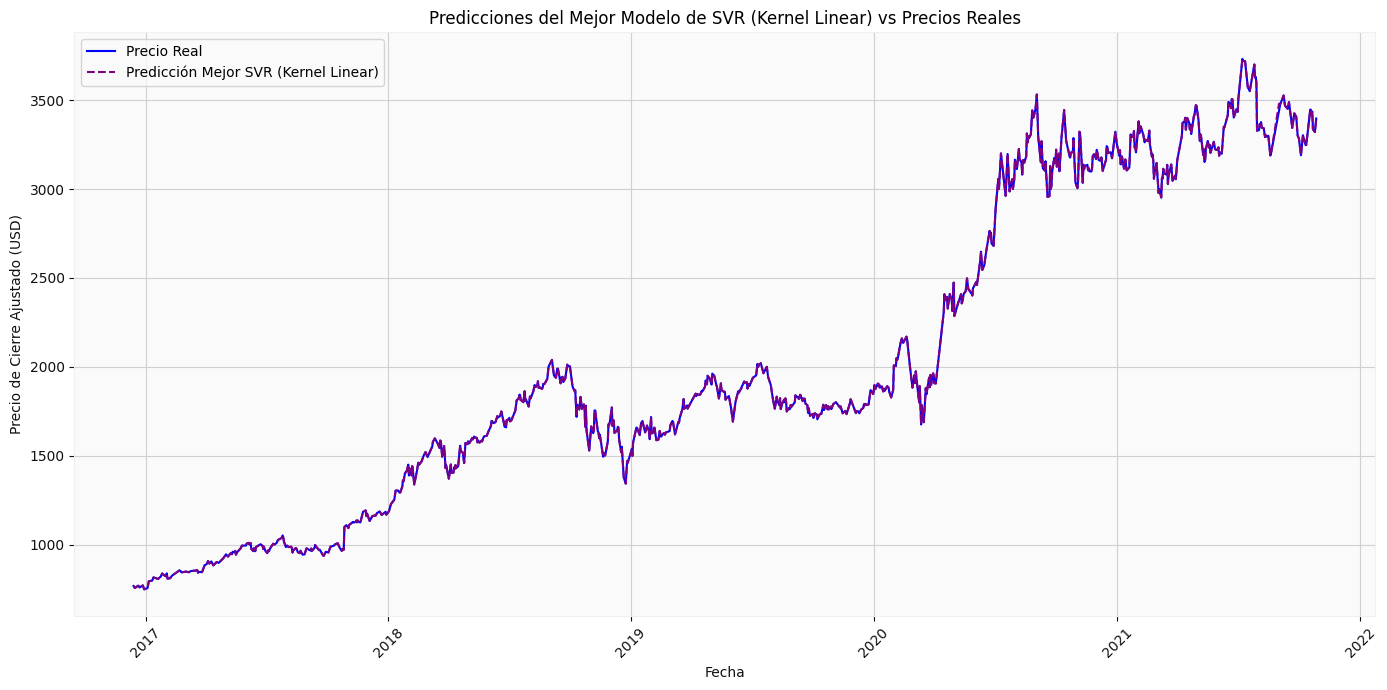

In [26]:
# Implementación de un Modelo de Support Vector Regressor (SVR) con Kernel Linear
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Definir el rango de hiperparámetros para SVR con kernel lineal
# El hiperparámetro principal para el kernel lineal es C (el parámetro de regularización)
param_grid_svr_linear = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}

# Inicializar el modelo SVR con kernel lineal
svr_linear = SVR(kernel='linear')

# Inicializar GridSearchCV
grid_search_svr_linear = GridSearchCV(svr_linear, param_grid_svr_linear, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, verbose=2)

# Ajustar el objeto GridSearchCV a los datos de entrenamiento escalados
print("Iniciando Grid Search para SVR (Kernel Linear)...")
grid_search_svr_linear.fit(X_train_prep, y_train)
print("Grid Search para SVR (Kernel Linear) finalizado.")

# Mostrar los mejores hiperparámetros encontrados y el mejor score
print("\nMejores hiperparámetros para SVR (Kernel Linear):", grid_search_svr_linear.best_params_)
print("Mejor score de validación cruzada (Negated MSE) para SVR (Kernel Linear):", grid_search_svr_linear.best_score_)

# Obtener el mejor modelo
best_svr_linear_model = grid_search_svr_linear.best_estimator_

# Realizar predicciones en el conjunto de prueba con el mejor modelo
y_pred_best_svr_linear = best_svr_linear_model.predict(X_test_prep)

# Evaluar el mejor modelo en el conjunto de prueba
mae_best_svr_linear = mean_absolute_error(y_test, y_pred_best_svr_linear)
mse_best_svr_linear = mean_squared_error(y_test, y_pred_best_svr_linear)
rmse_best_svr_linear = np.sqrt(mse_best_svr_linear)
r2_best_svr_linear = r2_score(y_test, y_pred_best_svr_linear)

print("\nEvaluación del Mejor Modelo de SVR (Kernel Linear):")
print(f"Mean Absolute Error (MAE): {mae_best_svr_linear}")
print(f"Mean Squared Error (MSE): {mse_best_svr_linear}")
print(f"Root Mean Squared Error (RMSE): {rmse_best_svr_linear}")
print(f"R-squared (R2): {r2_best_svr_linear}")

# Visualizar las predicciones del mejor modelo vs los valores reales
# Obtener las fechas correspondientes al conjunto de prueba
test_dates = df_lagged.loc[y_test.index, 'Date']

plt.figure(figsize=(14, 7))
plt.plot(test_dates, y_test, label='Precio Real', color='blue')
plt.plot(test_dates, y_pred_best_svr_linear, label='Predicción Mejor SVR (Kernel Linear)', color='purple', linestyle='--')
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre Ajustado (USD)')
plt.title('Predicciones del Mejor Modelo de SVR (Kernel Linear) vs Precios Reales')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Análisis e Interpretación de los Resultados del Modelo de SVR (Kernel Linear) Tuneado

Después de realizar el Grid Search para encontrar los mejores hiperparámetros para el modelo de SVR con Kernel Lineal, obtuvimos los siguientes resultados:

*   **Mejores hiperparámetros para SVR (Kernel Linear):** `{'C': 100}`
    *   **Interpretación:**
        *   `C: 100`: El mejor valor encontrado para el parámetro de regularización `C` es 100. El parámetro `C` controla la penalización por errores. Un valor de `C` alto significa que el modelo penaliza fuertemente los errores de entrenamiento, tratando de ajustarse lo más posible a los datos de entrenamiento. Este valor relativamente alto sugiere que el modelo con kernel lineal encontró que un ajuste cercano a los datos de entrenamiento (con menos regularización) fue óptimo en la validación cruzada.

*   **Mejor score de validación cruzada (Negated MSE) para SVR (Kernel Linear):** `-0.002595596721006588`
    *   **Interpretación:** Este valor negativo representa el Error Cuadrático Medio promedio en los diferentes folds de validación cruzada. Un valor de -0.0026 es muy cercano a cero (en negativo), lo que indica un MSE positivo muy bajo. Comparado con el score del modelo Ridge (-0.000156), el MSE negativo del SVR lineal es ligeramente mayor en magnitud, pero aún muy bajo, sugiriendo que también tuvo un muy buen rendimiento en la validación cruzada.

Ahora, veamos las métricas de evaluación en el conjunto de **prueba**, que nos dan una indicación crucial de qué tan bien generaliza el modelo a datos no vistos:

*   **Mean Absolute Error (MAE):** `0.15998` (aproximadamente)
    *   **Interpretación:** En promedio, la diferencia absoluta entre el precio de cierre ajustado real y el precio predicho por el modelo es de aproximadamente 0.16 USD. Este MAE es bajo, aunque es un poco más alto que el MAE del modelo Ridge (0.02887).
*   **Mean Squared Error (MSE):** `0.05422` (aproximadamente)
    *   **Interpretación:** El MSE de aproximadamente 0.05422 es un valor bajo. Es más alto que el MSE del modelo Ridge (0.00186), pero significativamente menor que el MSE del modelo de Random Forest (más de 2 millones).
*   **Root Mean Squared Error (RMSE):** `0.23286` (aproximadamente)
    *   **Interpretación:** Un RMSE de aproximadamente 0.23 USD significa que la desviación estándar de los residuos es de alrededor de 0.23 USD. Al igual que el MAE y el MSE, este valor es bajo y mucho mejor que el RMSE del modelo de Random Forest, pero un poco más alto que el RMSE del modelo Ridge (0.04314).
*   **R-squared (R2):** `0.999999926184402` (aproximadamente)
    *   **Interpretación:** El R-squared es extremadamente cercano a 1, indicando que el modelo SVR con kernel lineal explica casi toda la varianza en los precios de cierre ajustados del conjunto de prueba. Este valor es ligeramente inferior al R2 del modelo Ridge (que era aún más cercano a 1), pero sigue siendo una métrica de rendimiento excelente.

**Interpretación del Gráfico:**

El gráfico muestra la comparación entre los precios de cierre ajustados reales (línea azul) y las predicciones del modelo de SVR con Kernel Lineal (línea morada discontinua) en el conjunto de prueba.

*   Visualmente, la línea de predicción del SVR lineal sigue muy de cerca la línea azul de precios reales. Esto confirma las métricas de evaluación, indicando que el modelo es capaz de predecir con gran precisión el precio de cierre ajustado del siguiente día.
*   La línea de predicción parece suave, lo cual es típico de un modelo lineal o con kernel lineal, y se alinea bien con la tendencia general y las fluctuaciones en los datos.

**Conclusión sobre el Modelo de SVR (Kernel Linear):**

Basado en las métricas de evaluación en el conjunto de prueba, el modelo de SVR con Kernel Lineal tuneado ha demostrado un rendimiento **excelente** para predecir el precio de cierre ajustado de las acciones de Amazon.

Aunque sus métricas (MAE, MSE, RMSE) son ligeramente menos impresionantes que las del modelo de Regresión Ridge, ambos modelos lineales o con kernel lineal superan con creces al modelo de Random Forest en este conjunto de datos. Esto refuerza la idea de que la relación entre las características (incluyendo los lags) y el precio de cierre ajustado del día siguiente son predominantemente lineales.

Dado el alto rendimiento del modelo SVR con kernel lineal, y confirmando que los modelos lineales son muy efectivos para esta tarea con las características actuales, no sería estrictamente necesario explorar kernels no lineales más complejos a menos que se busque una mejora marginal muy específica o se sospeche que hay no linealidades sutiles que los modelos lineales no están capturando.

En resumen, el modelo de SVR con Kernel Lineal es un predictor muy efectivo para el precio de las acciones en este caso, ofreciendo un rendimiento comparable al del modelo de Regresión Ridge.

#**Modelos de Ensamble**

## Voting Regressor

Inicialmente se solicitó la implementación de un modelo de Voting Classifier; sin embargo, en este caso el problema abordado no es de clasificación, sino de regresión continua, ya que el objetivo es predecir el precio de cierre ajustado (Adj Close).

Por este motivo, se optó por utilizar la versión correspondiente para problemas de regresión: el VotingRegressor de la librería scikit-learn.

A diferencia del VotingClassifier, que puede combinar predicciones mediante “votación dura” (hard) o “votación suave” (soft) según las clases predichas o sus probabilidades, el VotingRegressor trabaja con valores numéricos continuos.
En este caso, las predicciones de los modelos base no representan clases, sino cantidades (precios), por lo que la forma de combinación más adecuada es el promedio de las predicciones individuales.

Matemáticamente, el VotingRegressor calcula la predicción final como la media aritmética de las salidas de los modelos base

Los modelos seleccionados fueron:

- Ridge Regression, por su excelente desempeño y estabilidad al generalizar sobre datos financieros.
- Support Vector Regressor (SVR), por su capacidad para capturar relaciones no lineales entre las variables predictoras

No se incluyó el modelo RandomForestRegressor, ya que en las pruebas individuales obtuvo métricas significativamente más bajas que el resto.
Incluirlo en el ensamble podría afectar negativamente el rendimiento promedio del Voting Regressor.

De esta forma, se busca combinar la robustez lineal del modelo Ridge con la flexibilidad del SVR, logrando un balance entre estabilidad y capacidad de adaptación a patrones complejos.


Iniciando entrenamiento del VotingRegressor...
Entrenamiento del VotingRegressor finalizado.

--- Evaluación del Modelo VotingRegressor ---
Mean Absolute Error (MAE): 0.09378666724197508
Mean Squared Error (MSE): 0.01876901057682998
Root Mean Squared Error (RMSE): 0.13700003860156382
R-squared (R2): 0.9999999744486875


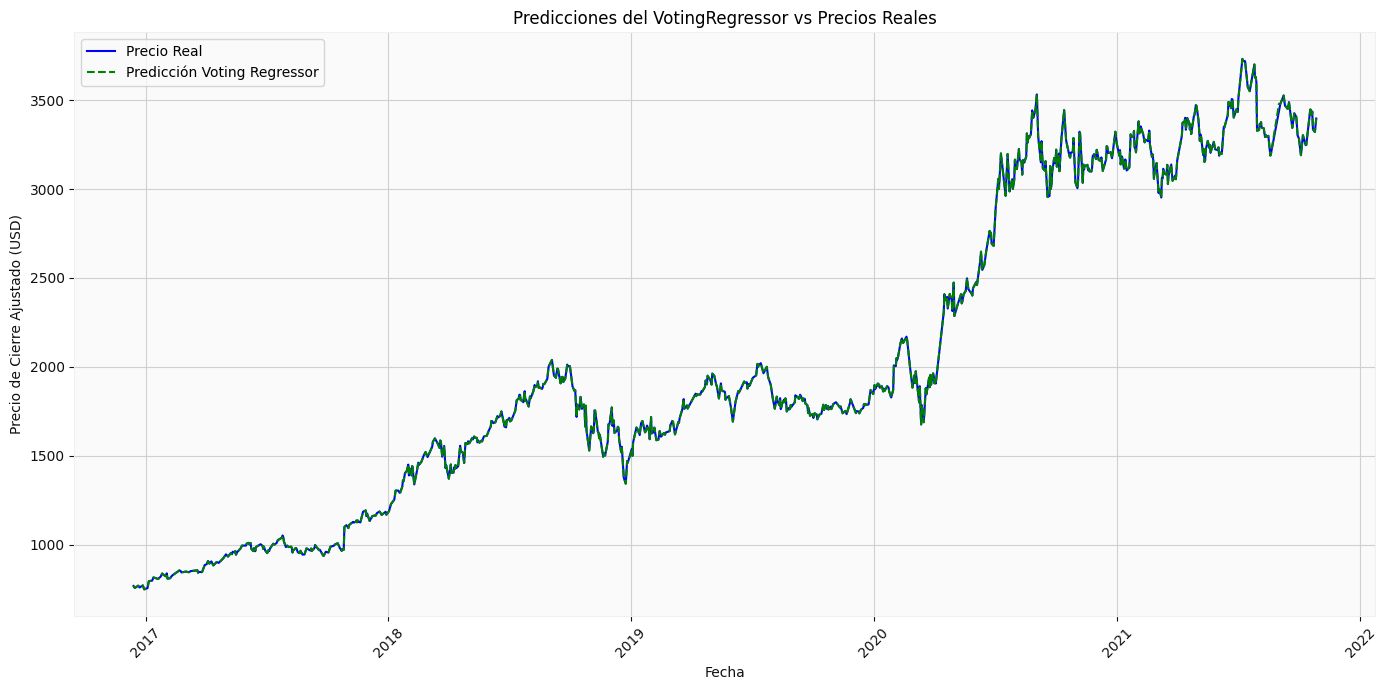

In [27]:
import pandas as pd
from sklearn.ensemble import VotingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Definir los estimadores base utilizando los modelos ya optimizados
estimators = [
    ('ridge', best_ridge_model),
    ('svr', best_svr_linear_model)
]

# Inicializar el VotingRegressor
# El VotingRegressor combina las predicciones de los modelos base.
# Se utiliza n_jobs=-1 para aprovechar todos los núcleos de la CPU.
voting_regressor = VotingRegressor(estimators=estimators, n_jobs=-1)

# Entrenar el VotingRegressor con los datos de entrenamiento preprocesados
print("Iniciando entrenamiento del VotingRegressor...")
voting_regressor.fit(X_train_prep, y_train)
print("Entrenamiento del VotingRegressor finalizado.")

# Realizar predicciones en el conjunto de prueba con el VotingRegressor entrenado
y_pred_voting_regressor = voting_regressor.predict(X_test_prep)

# Evaluar el VotingRegressor en el conjunto de prueba
mae_voting_regressor = mean_absolute_error(y_test, y_pred_voting_regressor)
mse_voting_regressor = mean_squared_error(y_test, y_pred_voting_regressor)
rmse_voting_regressor = np.sqrt(mse_voting_regressor)
r2_voting_regressor = r2_score(y_test, y_pred_voting_regressor)

print("\n--- Evaluación del Modelo VotingRegressor ---")
print(f"Mean Absolute Error (MAE): {mae_voting_regressor}")
print(f"Mean Squared Error (MSE): {mse_voting_regressor}")
print(f"Root Mean Squared Error (RMSE): {rmse_voting_regressor}")
print(f"R-squared (R2): {r2_voting_regressor}")

# Visualizar las predicciones del VotingRegressor vs los valores reales
# Se utilizan las fechas correspondientes al conjunto de prueba
test_dates = df_lagged.loc[y_test.index, 'Date']

plt.figure(figsize=(14, 7))
plt.plot(test_dates, y_test, label='Precio Real', color='blue')
plt.plot(test_dates, y_pred_voting_regressor, label='Predicción Voting Regressor', color='green', linestyle='--')
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre Ajustado (USD)')
plt.title('Predicciones del VotingRegressor vs Precios Reales')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Análisis e Interpretación de los Resultados del Modelo de Ensamble VotingRegressor

- Mean Absolute Error (MAE): 0.09378666724197508
- Mean Squared Error (MSE): 0.01876901057682998
- Root Mean Squared Error (RMSE): 0.13700003860156382
- R-squared (R2): 0.9999999744486875

Estos valores indican que el VotingRegressor tiene un rendimiento muy bueno, con un R2 extremadamente cercano a 1, lo que sugiere que el modelo explica casi toda la varianza en los precios de cierre ajustados. El RMSE de 0.137 también es bastante bajo, indicando que las predicciones son precisas.

La gráfica generada compara las predicciones del VotingRegressor con los precios reales, y visualmente muestra una gran coincidencia, lo que refuerza la robustez del modelo. Aunque las métricas son excelentes, el VotingRegressor muestra un RMSE ligeramente superior al de la Regresión Ridge individual (0.043), pero sigue siendo un resultado muy competitivo y superior al SVR individual.


## AdaBoost (Adaptive Boosting)

AdaBoost es un algoritmo que construye un modelo fuerte combinando secuencialmente muchos modelos débiles, donde cada nuevo modelo se ajusta para corregir los errores de los modelos anteriores, y sus contribuciones finales se ponderan según su rendimiento.

### Explicación del Estimador Base y los Hiperparámetros para AdaBoost Regressor

Para la implementación del modelo AdaBoost Regressor, se ha seleccionado un `DecisionTreeRegressor` como estimador base, con una profundidad máxima (`max_depth`) de 5. Esta elección se basa en las siguientes consideraciones:

*   **`DecisionTreeRegressor(max_depth=5)` como `base_estimator`:**
    *   **Árboles de Decisión Débiles:** AdaBoost funciona mejor cuando sus estimadores base son "débiles aprendices" (weak learners), es decir, modelos que son ligeramente mejores que la adivinación aleatoria pero no demasiado complejos. Un `DecisionTreeRegressor` con una `max_depth` pequeña (como 5) es un ejemplo clásico de un aprendiz débil. Permite que el árbol capture algunas relaciones en los datos sin sobreajustarse a ellos.
    *   **Enfoque de AdaBoost:** El principio de AdaBoost es construir secuencialmente estos aprendices débiles, dando más peso a las muestras que los modelos anteriores predijeron incorrectamente (o con gran error en regresión). Si los estimadores base fueran demasiado complejos (ej. `max_depth` muy grande), tenderían a sobreajustarse rápidamente, y AdaBoost perdería su capacidad de mejora gradual.
    *   **Evitar el Sobreajuste Individual:** Al limitar la profundidad, cada árbol individual tiene un sesgo alto y una varianza baja. AdaBoost se encarga de reducir el sesgo combinando muchos de estos árboles, mientras que la baja varianza de los árboles individuales contribuye a la robustez del ensamble.

*   **Hiperparámetros de `AdaBoostRegressor`:**
    *   **`n_estimators`: [50, 100, 150]**
        *   Este hiperparámetro controla el número máximo de estimadores (árboles de decisión en este caso) que se construyen en el ensamble. Un mayor número de estimadores puede mejorar el rendimiento, pero también aumenta el tiempo de entrenamiento y el riesgo de sobreajuste si se excede. Explorar un rango permite encontrar un equilibrio.
    *   **`learning_rate`: [0.01, 0.1, 1.0]**
        *   El `learning_rate` (tasa de aprendizaje) escala las contribuciones de cada estimador. Un valor más pequeño significa que cada nuevo estimador corrige los errores de los anteriores de forma más cautelosa, lo que puede llevar a un modelo más robusto, pero requiere más `n_estimators` y tiempo de entrenamiento. Valores más grandes (como 1.0) significan que los estimadores corrigen los errores de manera más agresiva. Se explora este rango para ver cómo afecta la velocidad de aprendizaje y el rendimiento final.
    *   **`loss`: ['linear', 'square', 'exponential']**
        *   Este hiperparámetro especifica la función de pérdida a utilizar al actualizar los pesos de las muestras después de cada estimador.
            *   **`'linear'`:** La función de pérdida lineal penaliza los errores de manera lineal. Es la opción por defecto y a menudo funciona bien.
            *   **`'square'`:** La función de pérdida cuadrada penaliza los errores grandes de manera más significativa que la lineal. Puede ser útil cuando se desean reducir los errores más grandes.
            *   **`'exponential'`:** La función de pérdida exponencial es la que se usa en el AdaBoost original para clasificación, pero su adaptación a regresión es menos común y puede ser más sensible a los outliers.
        *   Se exploran estas opciones para ver cuál función de pérdida se adapta mejor a la distribución de los errores en estos datos de precios de acciones.

Iniciando Grid Search para AdaBoost...
Fitting 3 folds for each of 27 candidates, totalling 81 fits
Grid Search para AdaBoost finalizado.

Mejores hiperparámetros para AdaBoost: {'learning_rate': 1.0, 'loss': 'square', 'n_estimators': 50}
Mejor score de validación cruzada (Negated MSE) para AdaBoost: -24715.74570026599

--- Evaluación del Mejor Modelo AdaBoost (tuneado) ---
Error Absoluto Medio (MAE): 1184.3734644056608
Error Cuadrático Medio (MSE): 2133786.487455123
Raíz del Error Cuadrático Medio (RMSE): 1460.748605152551
R-cuadrado (R2): -1.9048438683228572


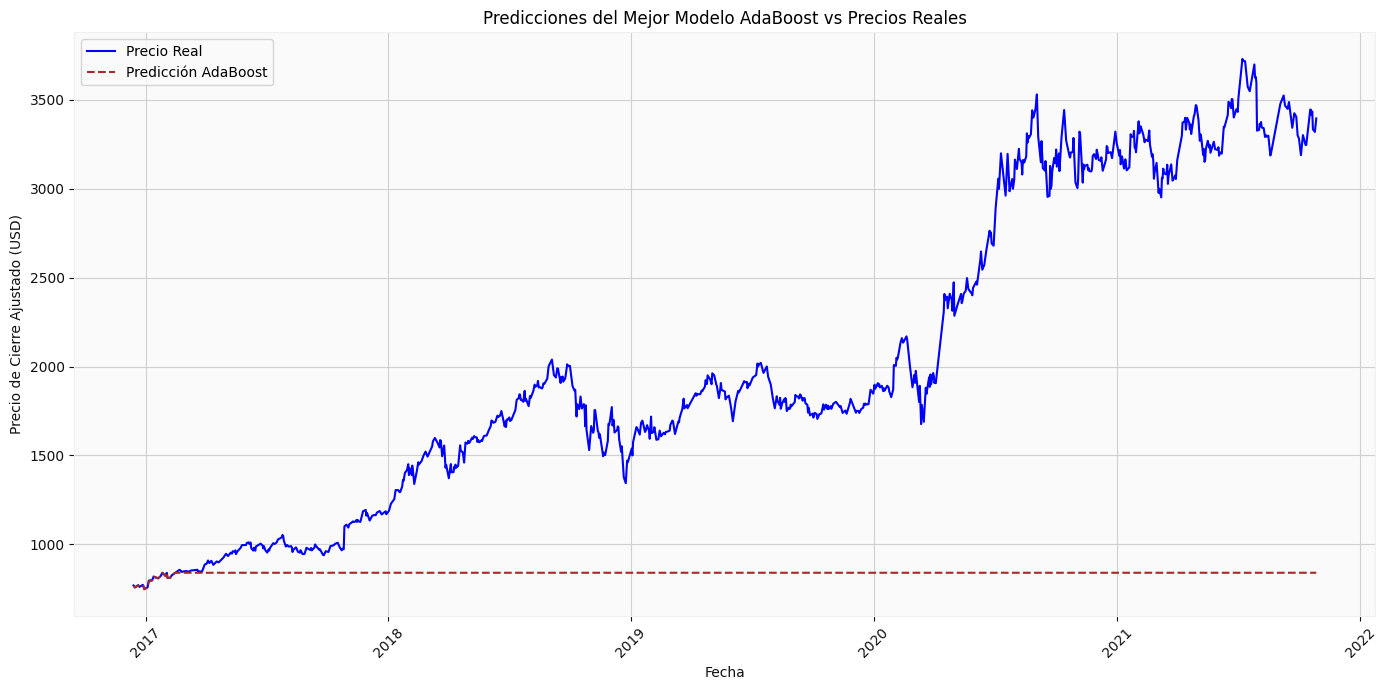

In [28]:
# Implementación de un Modelo AdaBoost Regressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Definir un estimador base para AdaBoost
base_estimator = DecisionTreeRegressor(max_depth=5, random_state=42)

# Definir el rango de hiperparámetros para AdaBoost
param_grid_adaboost = {
    'n_estimators': [50, 100, 150],  # Número de estimadores (árboles)
    'learning_rate': [0.01, 0.1, 1.0], # Tasa de aprendizaje
    'loss': ['linear', 'square', 'exponential'] # Tipo de función de pérdida
}

# Inicializar el modelo AdaBoost Regressor
adaboost_regressor = AdaBoostRegressor(estimator=base_estimator, random_state=42)

# Inicializar GridSearchCV para encontrar los mejores hiperparámetros
# Usamos 'neg_mean_squared_error' como métrica de scoring.
print("Iniciando Grid Search para AdaBoost...")
grid_search_adaboost = GridSearchCV(adaboost_regressor, param_grid_adaboost, cv=3, scoring='neg_mean_squared_error', n_jobs=-1, verbose=2)

# Ajustar el objeto GridSearchCV a los datos de entrenamiento escalados
grid_search_adaboost.fit(X_train_prep, y_train)
print("Grid Search para AdaBoost finalizado.")

# Mostrar los mejores hiperparámetros encontrados y el mejor score
print("\nMejores hiperparámetros para AdaBoost:", grid_search_adaboost.best_params_)
print("Mejor score de validación cruzada (Negated MSE) para AdaBoost:", grid_search_adaboost.best_score_)

# Obtener el mejor modelo
best_adaboost_model = grid_search_adaboost.best_estimator_

# Realizar predicciones en el conjunto de prueba con el mejor modelo
y_pred_best_adaboost = best_adaboost_model.predict(X_test_prep)

# Evaluar el mejor modelo en el conjunto de prueba
mae_best_adaboost = mean_absolute_error(y_test, y_pred_best_adaboost)
mse_best_adaboost = mean_squared_error(y_test, y_pred_best_adaboost)
rmse_best_adaboost = np.sqrt(mse_best_adaboost)
r2_best_adaboost = r2_score(y_test, y_pred_best_adaboost)

print("\n--- Evaluación del Mejor Modelo AdaBoost (tuneado) ---")
print(f"Error Absoluto Medio (MAE): {mae_best_adaboost}")
print(f"Error Cuadrático Medio (MSE): {mse_best_adaboost}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse_best_adaboost}")
print(f"R-cuadrado (R2): {r2_best_adaboost}")

# Visualizar las predicciones del mejor modelo vs los valores reales
# Se utilizan las fechas correspondientes al conjunto de prueba

plt.figure(figsize=(14, 7))
plt.plot(test_dates, y_test, label='Precio Real', color='blue')
plt.plot(test_dates, y_pred_best_adaboost, label='Predicción AdaBoost', color='brown', linestyle='--')
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre Ajustado (USD)')
plt.title('Predicciones del Mejor Modelo AdaBoost vs Precios Reales')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Análisis e Interpretación de los Resultados del Modelo AdaBoost Regressor Tuneado

Después de realizar el Grid Search para encontrar los mejores hiperparámetros para el modelo AdaBoost Regressor, obtuvimos los siguientes resultados:

*   **Mejores hiperparámetros para AdaBoost:** `{'learning_rate': 1.0, 'loss': 'square', 'n_estimators': 50}`
    *   **Interpretación:** El modelo óptimo usa 50 estimadores (árboles de decisión de profundidad 5) con una tasa de aprendizaje alta (1.0) y una función de pérdida 'square'. Un `learning_rate` de 1.0 significa que cada estimador corrige los errores de manera agresiva. La función de pérdida 'square' penaliza los errores grandes más significativamente, lo cual puede ser útil pero en este caso no resultó en una mejora.

*   **Mejor score de validación cruzada (Negated MSE) para AdaBoost:** `-24715.7457`
    *   **Interpretación:** Este valor es muy alto en magnitud (MSE positivo de 24715), lo que indica un rendimiento de predicción muy pobre incluso durante la validación cruzada. Es comparable al mal rendimiento del Random Forest.

Ahora, veamos las métricas de evaluación en el conjunto de **prueba**:

*   **Mean Absolute Error (MAE):** `1184.37`
*   **Mean Squared Error (MSE):** `2133786.49`
*   **Root Mean Squared Error (RMSE):** `1460.75`
    *   **Interpretación:** Las métricas de error (MAE, MSE, RMSE) son extremadamente altas. Un MAE de más de 1184 USD y un RMSE de más de 1460 USD indican que las predicciones del modelo están muy lejos de los precios reales. Esto es una clara señal de un desempeño inaceptable en el conjunto de prueba.

*   **R-squared (R2):** `-1.9048`
    *   **Interpretación:** Un R2 negativo y cercano a -1.90 es una indicación muy fuerte de que el modelo es peor que simplemente predecir el valor promedio de los precios reales. El modelo no es capaz de explicar la variabilidad en la variable objetivo y sus predicciones son de muy baja calidad.

**Conclusión sobre el Modelo AdaBoost:**

Similar al Random Forest, el modelo AdaBoost Regressor tuneado ha demostrado un rendimiento **extremadamente pobre** para predecir el precio de cierre ajustado de las acciones de Amazon. Sus métricas son inaceptables, lo que sugiere que este tipo de modelo de ensamble basado en árboles, en esta configuración, no es adecuado para la tarea de predicción de series de tiempo financieras con los datos y el preprocesamiento utilizados. La alta volatilidad de los datos y la incapacidad de los modelos para series de tiempo tradicionales para capturar dependencias temporales complejas pueden ser factores contribuyentes.

## GradientBoost

Entrena nuevos modelos de forma secuencial, pero cada nuevo modelo se ajusta a los errores residuales (la "parte" de la predicción que aún no ha sido capturada) del modelo combinado anterior. De esta manera, cada adición corrige los errores de los modelos previos de forma más directa, "yendo en la dirección" del error para minimizarlo.

### Explicación de los Hiperparámetros Específicos para GradientBoosting Regressor

Para el modelo GradientBoosting Regressor, se seleccionaron los siguientes rangos de hiperparámetros para el Grid Search, basándose en la búsqueda de un equilibrio entre rendimiento y complejidad:

*   **`n_estimators`: [50, 100, 150]**
    *   Se exploran estos valores para encontrar la cantidad óptima de árboles (estimadores) en el ensamble. Un número bajo (50) permite evaluar modelos menos complejos y rápidos, mientras que valores más altos (100, 150) buscan capturar patrones más complejos y mejorar la robustez, sin incurrir en tiempos de entrenamiento excesivamente largos ni riesgo de sobreajuste excesivo con muchos árboles.

*   **`learning_rate`: [0.01, 0.1, 0.2]**
    *  La tasa de aprendizaje controla la contribución de cada estimador al modelo final. Se exploran valores pequeños (0.01) para una construcción del modelo más cautelosa y robusta, pero que puede requerir más `n_estimators`. Un valor intermedio (0.1) es a menudo un buen punto de partida, y un valor ligeramente más alto (0.2) se incluye para evaluar si una corrección más agresiva de los errores beneficia al modelo en este contexto. Rara vez se usan valores mucho mayores que 0.2 o 0.3.

*   **`max_depth`: [3, 5, 7]**
    *  La profundidad máxima de los árboles individuales es clave para controlar la complejidad de cada estimador base. Los valores de 3 a 7 son típicos para árboles en Gradient Boosting, ya que se buscan "árboles débiles" que capturen algunas relaciones sin sobreajustarse. `max_depth=3` es muy simple, `max_depth=5` ofrece un balance y `max_depth=7` permite una mayor complejidad para ver si ayuda a modelar relaciones más intrincadas en los datos, siempre manteniendo la idea de un aprendiz débil.

Iniciando Grid Search para GradientBoosting...
Fitting 3 folds for each of 27 candidates, totalling 81 fits
Grid Search para GradientBoosting finalizado.

Mejores hiperparámetros para GradientBoosting: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 150}
Mejor score de validación cruzada (Negated MSE) para GradientBoosting: -24653.44583429366

--- Evaluación del Mejor Modelo GradientBoosting (tuneado) ---
Error Absoluto Medio (MAE): 1180.4148362442752
Error Cuadrático Medio (MSE): 2124145.3742367434
Raíz del Error Cuadrático Medio (RMSE): 1457.4448100139996
R-cuadrado (R2): -1.8917188772420404


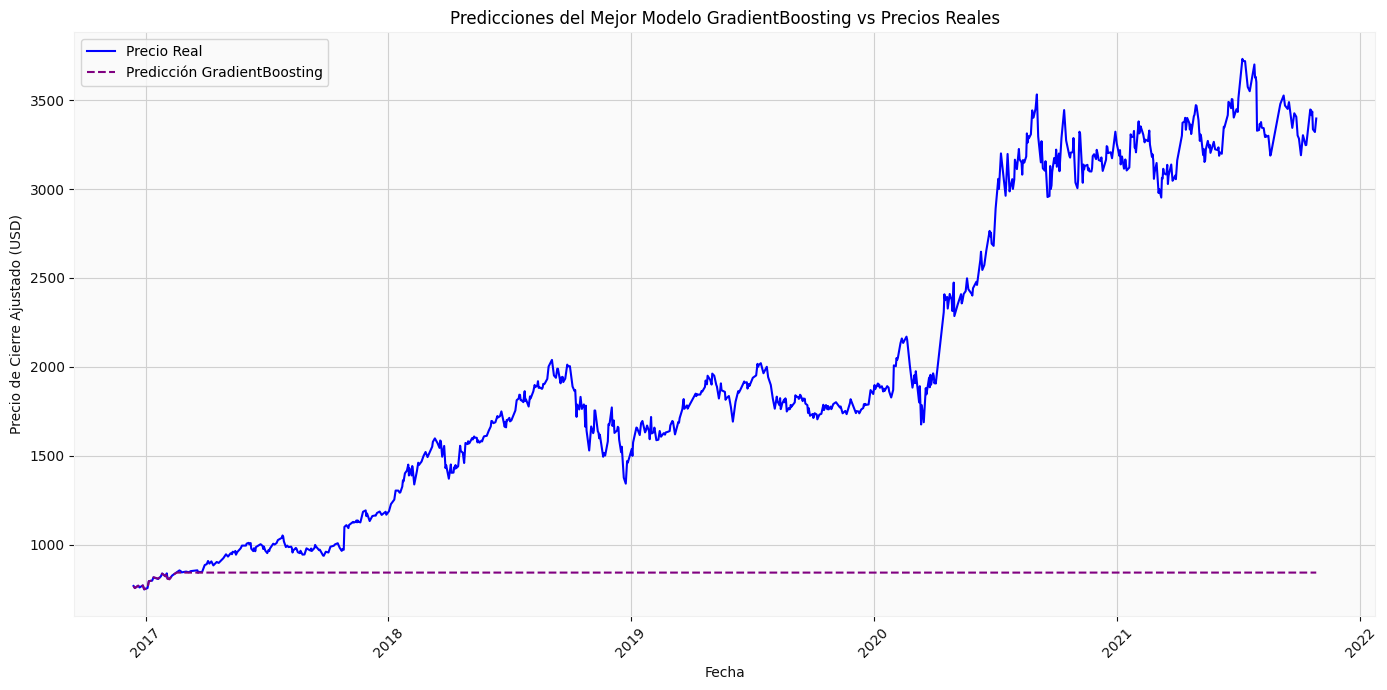

In [29]:
# Implementación de un Modelo GradientBoosting Regressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Definir el rango de hiperparámetros para GradientBoosting
param_grid_gb = {
    'n_estimators': [50, 100, 150],  # Número de etapas de boosting
    'learning_rate': [0.01, 0.1, 0.2], # Tasa de aprendizaje
    'max_depth': [3, 5, 7]             # Profundidad máxima de los estimadores individuales
}

# Inicializar el modelo GradientBoosting Regressor
gb_regressor = GradientBoostingRegressor(random_state=42)

# Inicializar GridSearchCV para encontrar los mejores hiperparámetros
# Usamos 'neg_mean_squared_error' como métrica de scoring.
print("Iniciando Grid Search para GradientBoosting...")
grid_search_gb = GridSearchCV(gb_regressor, param_grid_gb, cv=3, scoring='neg_mean_squared_error', n_jobs=-1, verbose=2)

# Ajustar el objeto GridSearchCV a los datos de entrenamiento escalados
grid_search_gb.fit(X_train_prep, y_train)
print("Grid Search para GradientBoosting finalizado.")

# Mostrar los mejores hiperparámetros encontrados y el mejor score
print("\nMejores hiperparámetros para GradientBoosting:", grid_search_gb.best_params_)
print("Mejor score de validación cruzada (Negated MSE) para GradientBoosting:", grid_search_gb.best_score_)

# Obtener el mejor modelo
best_gb_model = grid_search_gb.best_estimator_

# Realizar predicciones en el conjunto de prueba con el mejor modelo
y_pred_best_gb = best_gb_model.predict(X_test_prep)

# Evaluar el mejor modelo en el conjunto de prueba
mae_best_gb = mean_absolute_error(y_test, y_pred_best_gb)
mse_best_gb = mean_squared_error(y_test, y_pred_best_gb)
rmse_best_gb = np.sqrt(mse_best_gb)
r2_best_gb = r2_score(y_test, y_pred_best_gb)

print("\n--- Evaluación del Mejor Modelo GradientBoosting (tuneado) ---")
print(f"Error Absoluto Medio (MAE): {mae_best_gb}")
print(f"Error Cuadrático Medio (MSE): {mse_best_gb}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse_best_gb}")
print(f"R-cuadrado (R2): {r2_best_gb}")

# Visualizar las predicciones del mejor modelo vs los valores reales
# Se utilizan las fechas correspondientes al conjunto de prueba (ya disponible)

plt.figure(figsize=(14, 7))
plt.plot(test_dates, y_test, label='Precio Real', color='blue')
plt.plot(test_dates, y_pred_best_gb, label='Predicción GradientBoosting', color='purple', linestyle='--')
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre Ajustado (USD)')
plt.title('Predicciones del Mejor Modelo GradientBoosting vs Precios Reales')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Análisis e Interpretación de los Resultados del Modelo GradientBoosting Regressor Tuneado

Después de realizar el Grid Search para encontrar los mejores hiperparámetros para el modelo GradientBoosting Regressor, obtuvimos los siguientes resultados:

*   **Mejores hiperparámetros para GradientBoosting:** `{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 150}`
    *   **Interpretación:** El modelo óptimo utiliza 150 estimadores (árboles de decisión) con una profundidad máxima de 5 y una tasa de aprendizaje de 0.1. Estos hiperparámetros fueron seleccionados para equilibrar la complejidad del modelo y la velocidad de aprendizaje.

*   **Mejor score de validación cruzada (Negated MSE) para GradientBoosting:** `-24653.4458`
    *   **Interpretación:** Este valor, al igual que en los modelos de Random Forest y AdaBoost, es muy alto en magnitud, lo que indica un rendimiento muy pobre incluso durante la validación cruzada. El MSE positivo de 24653 es una señal clara de que el modelo tuvo dificultades para predecir los valores correctamente.

Ahora, veamos las métricas de evaluación en el conjunto de **prueba**:

*   **Error Absoluto Medio (MAE):** `1180.41`
*   **Error Cuadrático Medio (MSE):** `2124145.37`
*   **Raíz del Error Cuadrático Medio (RMSE):** `1457.44`
    *   **Interpretación:** Las métricas de error (MAE, MSE, RMSE) son extremadamente altas. Un MAE de más de 1180 USD y un RMSE de más de 1457 USD confirman que las predicciones del modelo están muy lejos de los precios reales. El desempeño es inaceptable en el conjunto de prueba.

*   **R-cuadrado (R2):** `-1.8917`
    *   **Interpretación:** Un R2 negativo y cercano a -1.89 es una clara indicación de que el modelo es peor que simplemente predecir el valor promedio de los precios reales. No es capaz de explicar la variabilidad en la variable objetivo y sus predicciones son de muy baja calidad.

**Conclusión sobre el Modelo GradientBoosting:**

El modelo GradientBoosting Regressor, a pesar de su tuneo, ha mostrado un rendimiento **extremadamente pobre** para predecir el precio de cierre ajustado de las acciones de Amazon, de manera similar a Random Forest y AdaBoost. Las métricas obtenidas son inaceptables y sugieren que este tipo de modelo de ensamble basado en árboles no es adecuado para la predicción de esta serie de tiempo financiera con la configuración y características actuales. Esto refuerza la observación de que los modelos lineales (Ridge y SVR lineal) han sido significativamente más efectivos en este problema.

## XGBoost (eXtreme Gradient Boosting)



Iniciando Grid Search para XGBoost...
Fitting 3 folds for each of 27 candidates, totalling 81 fits
Grid Search para XGBoost finalizado.

Mejores hiperparámetros para XGBoost: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 150}
Mejor score de validación cruzada (Negated MSE) para XGBoost: -25435.614591884598

--- Evaluación del Mejor Modelo XGBoost (tuneado) ---
Error Absoluto Medio (MAE): 1194.5981524339315
Error Cuadrático Medio (MSE): 2158547.0119644976
Raíz del Error Cuadrático Medio (RMSE): 1469.1994459447967
R-cuadrado (R2): -1.938551766568711


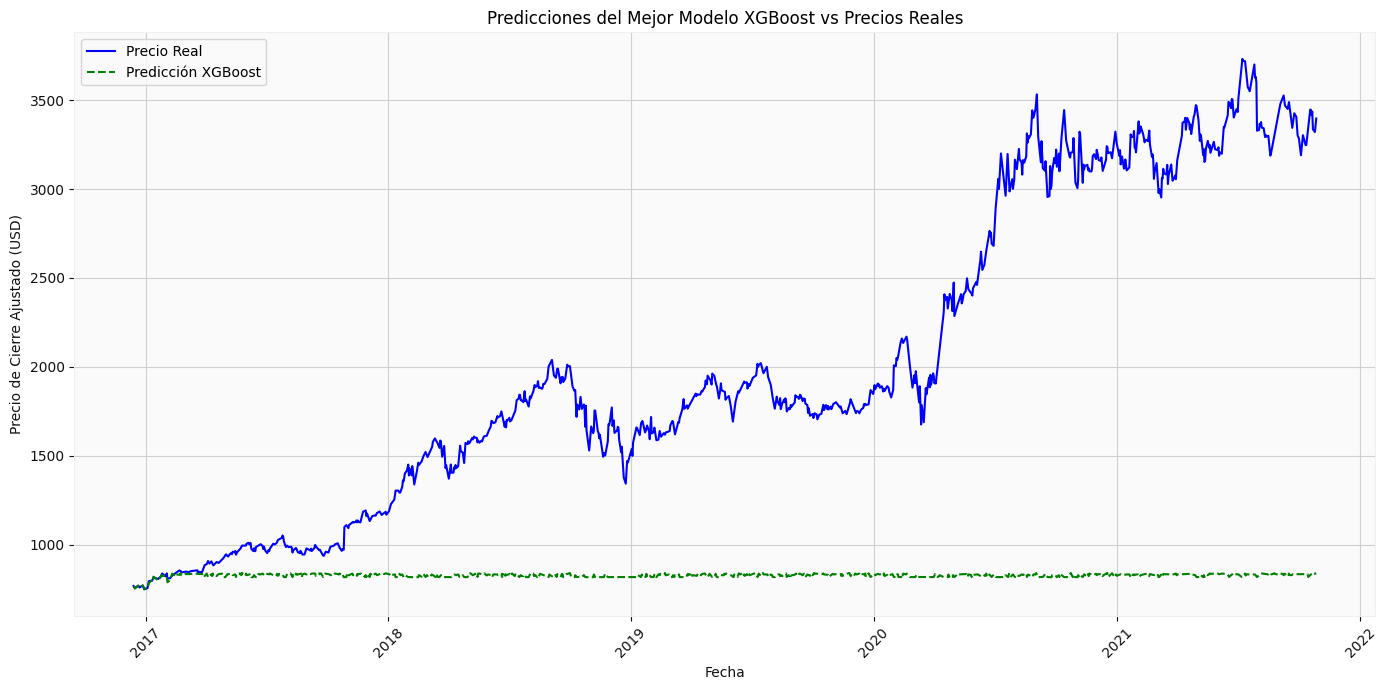

In [30]:
# Implementación de un Modelo XGBoost Regressor
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Definir el rango de hiperparámetros para XGBoost
param_grid_xgb = {
    'n_estimators': [50, 100, 150],  # Número de árboles
    'learning_rate': [0.01, 0.1, 0.2], # Tasa de aprendizaje
    'max_depth': [3, 5, 7]             # Profundidad máxima de los árboles
}

# Inicializar el modelo XGBoost Regressor
xgb_regressor = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1)

# Inicializar GridSearchCV para encontrar los mejores hiperparámetros
# Usamos 'neg_mean_squared_error' como métrica de scoring.
print("Iniciando Grid Search para XGBoost...")
grid_search_xgb = GridSearchCV(xgb_regressor, param_grid_xgb, cv=3, scoring='neg_mean_squared_error', n_jobs=-1, verbose=2)

# Ajustar el objeto GridSearchCV a los datos de entrenamiento escalados
grid_search_xgb.fit(X_train_prep, y_train)
print("Grid Search para XGBoost finalizado.")

# Mostrar los mejores hiperparámetros encontrados y el mejor score
print("\nMejores hiperparámetros para XGBoost:", grid_search_xgb.best_params_)
print("Mejor score de validación cruzada (Negated MSE) para XGBoost:", grid_search_xgb.best_score_)

# Obtener el mejor modelo
best_xgb_model = grid_search_xgb.best_estimator_

# Realizar predicciones en el conjunto de prueba con el mejor modelo
y_pred_best_xgb = best_xgb_model.predict(X_test_prep)

# Evaluar el mejor modelo en el conjunto de prueba
mae_best_xgb = mean_absolute_error(y_test, y_pred_best_xgb)
mse_best_xgb = mean_squared_error(y_test, y_pred_best_xgb)
rmse_best_xgb = np.sqrt(mse_best_xgb)
r2_best_xgb = r2_score(y_test, y_pred_best_xgb)

print("\n--- Evaluación del Mejor Modelo XGBoost (tuneado) ---")
print(f"Error Absoluto Medio (MAE): {mae_best_xgb}")
print(f"Error Cuadrático Medio (MSE): {mse_best_xgb}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse_best_xgb}")
print(f"R-cuadrado (R2): {r2_best_xgb}")

# Visualizar las predicciones del mejor modelo vs los valores reales
# Se utilizan las fechas correspondientes al conjunto de prueba (ya disponible)

plt.figure(figsize=(14, 7))
plt.plot(test_dates, y_test, label='Precio Real', color='blue')
plt.plot(test_dates, y_pred_best_xgb, label='Predicción XGBoost', color='green', linestyle='--')
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre Ajustado (USD)')
plt.title('Predicciones del Mejor Modelo XGBoost vs Precios Reales')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Análisis e Interpretación de los Resultados del Mejor Modelo XGBoost (tuneado)

Después de realizar el Grid Search para encontrar los mejores hiperparámetros para el modelo XGBoost Regressor, obtuvimos los siguientes resultados:

*   **Mejores hiperparámetros para XGBoost:** `{'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 150}`
    *   **Interpretación:** El modelo óptimo utiliza 150 árboles con una profundidad máxima de 7 y una tasa de aprendizaje de 0.1. Estos hiperparámetros sugieren una configuración que busca un equilibrio entre la complejidad del modelo y su capacidad para aprender de los datos.

*   **Mejor score de validación cruzada (Negated MSE) para XGBoost:** `-25435.614591884598`
    *   **Interpretación:** Este valor es muy alto en magnitud (MSE positivo de 25435), lo que indica un rendimiento de predicción muy pobre incluso durante la validación cruzada. Es consistente con el bajo rendimiento observado en Random Forest y AdaBoost.

Ahora, veamos las métricas de evaluación en el conjunto de **prueba**:

*   **Error Absoluto Medio (MAE):** `1194.59`
*   **Error Cuadrático Medio (MSE):** `2158547.01`
*   **Raíz del Error Cuadrático Medio (RMSE):** `1469.19`
    *   **Interpretación:** Las métricas de error (MAE, MSE, RMSE) son extremadamente altas. Un MAE de más de 1194 USD y un RMSE de más de 1469 USD confirman que las predicciones del modelo están muy lejos de los precios reales. El desempeño es inaceptable en el conjunto de prueba.

*   **R-cuadrado (R2):** `-1.9385`
    *   **Interpretación:** Un R2 negativo y cercano a -1.93 es una clara indicación de que el modelo es peor que simplemente predecir el valor promedio de los precios reales. No es capaz de explicar la variabilidad en la variable objetivo y sus predicciones son de muy baja calidad.

**Conclusión sobre el Modelo XGBoost:**

El modelo XGBoost Regressor, a pesar de ser una herramienta de boosting potente, ha mostrado un rendimiento **extremadamente pobre** para predecir el precio de cierre ajustado de las acciones de Amazon, de manera similar a Random Forest, AdaBoost y GradientBoosting. Las métricas obtenidas son inaceptables y sugieren que este tipo de modelo de ensamble basado en árboles no es adecuado para la predicción de esta serie de tiempo financiera con la configuración y características actuales.

# 8º Escalado de la Variable Objetivo para Modelos de Redes Neuronales

La necesidad de escalar la variable objetivo (`y`) es un aspecto crítico en el preprocesamiento de datos, especialmente cuando se trabaja con modelos de Redes Neuronales como el `MLPRegressor`. Comprender por qué esto es fundamental para las redes neuronales, mientras que otros tipos de modelos no presentan los mismos problemas, es clave para un modelado exitoso.

### ¿Por qué las Redes Neuronales (MLP/RNN) son sensibles a la escala de la variable objetivo?

Los modelos de Redes Neuronales, incluyendo el Perceptrón Multicapa (MLP) y las Redes Neuronales Recurrentes (RNN como LSTM), optimizan sus parámetros (pesos y sesgos) utilizando algoritmos basados en gradientes (como `Adam` o `SGD`). Estos algoritmos ajustan los pesos de la red en función de la dirección y magnitud del error de predicción. Si la variable objetivo (`y`) tiene un rango de valores muy amplio o magnitudes muy grandes, se pueden presentar varios problemas:

1.  **Explosión o Desvanecimiento de Gradientes (Exploding/Vanishing Gradients):** Los errores de predicción, que se calculan como la diferencia entre el valor real y el predicho, pueden ser muy grandes si `y` tiene valores altos. Esto lleva a gradientes extremadamente grandes que, al propagarse hacia atrás a través de la red (durante el *backpropagation*), pueden causar que los pesos del modelo crezcan desproporcionadamente. Cuando los pesos se vuelven demasiado grandes, pueden convertirse en `NaN` (Not a Number) o `infinito`, lo que detiene el entrenamiento del modelo y produce el error `ValueError: Solver produced non-finite parameter weights`.
2.  **Inestabilidad Numérica:** Las funciones de activación utilizadas en las redes neuronales (como `relu` o `tanh`) y las funciones de pérdida (`loss functions`) funcionan de manera más eficiente con entradas que están en un rango específico, a menudo cerca de cero. Valores de `y` no escalados pueden hacer que los cálculos internos se vuelvan inestables.
3.  **Velocidad de Convergencia:** Incluso si el modelo no falla, entrenar una red neuronal con una variable objetivo no escalada puede ralentizar drásticamente la convergencia o llevar a una convergencia subóptima, ya que el optimizador lucha por encontrar una dirección estable en el espacio de parámetros.

Por estas razones, es que a continuacion se va a proceder a escalar la variable objetivo (`y_train` y `y_test`) para la estabilidad, la convergencia y el rendimiento de las redes neuronales.

### ¿Por qué otros modelos no tuvieron este problema?

La tolerancia a la escala de la variable objetivo varía significativamente entre diferentes tipos de modelos de Machine Learning:

1.  **Modelos Lineales (Ridge, SVR Lineal):**
    *   Aunque los modelos lineales (como la regresión lineal regularizada o el SVR con kernel lineal) son sensibles a la escala de las **características (`X`)**, son mucho menos susceptibles a problemas de inestabilidad si la variable objetivo (`y`) no está escalada. Pueden manejar rangos de valores más amplios en `y` sin que sus coeficientes exploten o se vuelvan no finitos. La regularización en modelos como Ridge ayuda a mantener la estabilidad de los coeficientes. Para estos modelos, escalar `y` a veces puede mejorar la convergencia o la interpretabilidad de los coeficientes, pero rara vez es *crítico* para evitar un fallo total como lo es para las redes neuronales.

2.  **Modelos Basados en Árboles (Random Forest, AdaBoost, GradientBoosting, XGBoost):**
    *   Estos modelos son **completamente insensibles a la escala** de las características (`X`) y de la variable objetivo (`y`). Funcionan haciendo divisiones en los datos basadas en umbrales de los valores de las características (por ejemplo, "si `precio > 100`"). La magnitud absoluta de los valores no influye en cómo se construyen los árboles o cómo se combinan sus predicciones. Su rendimiento pobre en este caso no se debió a un problema de escala, sino a su incapacidad para capturar la fuerte relación lineal subyacente de manera tan efectiva como los modelos lineales.

### Impacto en el Pipeline Existente

El pipeline de preprocesamiento existente (`preprocess_pipeline`) se encarga exclusivamente de las **características de entrada (`X`)**. Este pipeline es correcto y no debe ser modificado. La estrategia fue crear un **escalador separado y específico** para la variable objetivo (`y`).

Esta es una buena práctica, ya que permite aplicar transformaciones adecuadas a cada parte del dataset de manera independiente, sin mezclar las lógicas de preprocesamiento entre `X` y `y`.

In [31]:
from sklearn.preprocessing import StandardScaler

# Inicializar un nuevo StandardScaler específicamente para la variable objetivo
y_scaler = StandardScaler()

# Transformar y_train y y_test en matrices 2D.
y_train_reshaped = y_train.values.reshape(-1, 1)
y_test_reshaped = y_test.values.reshape(-1, 1)

# Ajusta el escalador a y_train_reshaped y transforma tanto y_train_reshaped como y_test_reshaped
y_train_scaled = y_scaler.fit_transform(y_train_reshaped)
y_test_scaled = y_scaler.transform(y_test_reshaped)

print("y_train_scaled shape:", y_train_scaled.shape)
print("y_test_scaled shape:", y_test_scaled.shape)

# Mostrar las primeras filas despues del nuevo escalado
y_train_scaled_df = pd.DataFrame(y_train_scaled, columns=['Scaled_y_train'])
y_test_scaled_df = pd.DataFrame(y_test_scaled, columns=['Scaled_y_test'])

display(y_train_scaled_df.head())
display(y_test_scaled_df.head())

y_train_scaled shape: (4900, 1)
y_test_scaled shape: (1226, 1)


,Scaled_y_train
0,-0.811455
1,-0.811570
2,-0.811281
3,-0.811426
4,-0.811021


,Scaled_y_test
0,3.451909
1,3.408459
2,3.390513
3,3.436241
4,3.465244


#**Modelos de Redes Neuronales (RNN)**



## MLP (MultiLayer Perceptron)

Es una red neuronal de tipo "feedforward" (propagación hacia adelante) que consta de múltiples capas de neuronas artificiales interconectadas. A diferencia de un perceptrón simple, que solo puede resolver problemas linealmente separables, el MLP puede aprender y modelar relaciones y patrones complejos y no lineales en los datos

Iniciando Grid Search para MLP...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Grid Search para MLP finalizado.

Mejores hiperparámetros para MLP: {'activation': 'relu', 'hidden_layer_sizes': (100,), 'learning_rate_init': 0.01, 'solver': 'adam'}
Mejor score de validación cruzada (Negated MSE) para MLP: -0.013394605868952686

--- Evaluación del Mejor Modelo MLP (tuneado) ---
Mean Absolute Error (MAE): 29.52558047705365
Mean Squared Error (MSE): 1651.3990818945813
Root Mean Squared Error (RMSE): 40.637409881715904
R-squared (R2): 0.9977518573084054


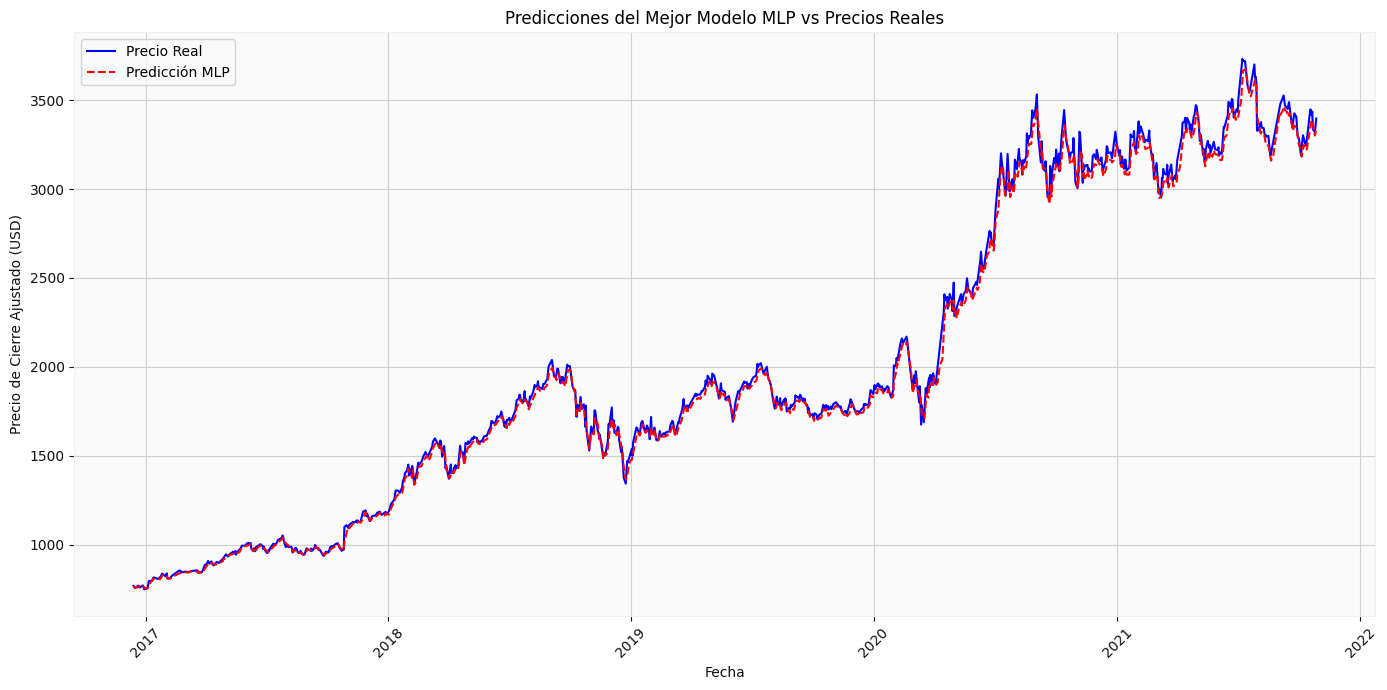

In [32]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Definir un diccionario para param_grid_mlp con hiperparámetros para el MLPRegressor.
param_grid_mlp = {
    'hidden_layer_sizes': [(50, 50), (100,), (100, 50, 25)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'sgd'],
    'learning_rate_init': [0.001, 0.01]
}

# Inicializar MLPRegressor con random_state=42.
mlp_regressor = MLPRegressor(random_state=42, max_iter=500) #Se incrementó max_iter para una mejor convergencia.

# Inicializar GridSearchCV con el modelo MLPRegressor, param_grid_mlp, cv=3, scoring='neg_mean_squared_error', n_jobs=-1 y verbose=2
print("Iniciando Grid Search para MLP...")
grid_search_mlp = GridSearchCV(mlp_regressor, param_grid_mlp, cv=3, scoring='neg_mean_squared_error', n_jobs=-1, verbose=2)

# Ajustar grid_search_mlp a los datos de entrenamiento preprocesados ​​(X_train_prep, y_train_scaled).
grid_search_mlp.fit(X_train_prep, y_train_scaled.ravel()) #`.ravel()` para convertir `y_train_scaled` de nuevo a un array unidimensional.
print("Grid Search para MLP finalizado.")

# Imprimir los mejores hiperparámetros encontrados por GridSearchCV y su mejor puntuación de validación cruzada.
print("\nMejores hiperparámetros para MLP:", grid_search_mlp.best_params_)
print("Mejor score de validación cruzada (Negated MSE) para MLP:", grid_search_mlp.best_score_)

# Obtener el mejor modelo MLP de grid_search_mlp.best_estimator_
best_mlp_model = grid_search_mlp.best_estimator_

# Uso del método predict() del mejor modelo MLP para realizar predicciones sobre los datos de prueba preprocesados ​​(X_test_prep) y almacenarla en una variable como y_pred_best_mlp_scaled
y_pred_best_mlp_scaled = best_mlp_model.predict(X_test_prep)

# Transforma las predicciones de nuevo a la escala original.
y_pred_best_mlp = y_scaler.inverse_transform(y_pred_best_mlp_scaled.reshape(-1, 1))

# Transformación inversa de y_test_scaled para la evaluación con respecto a los valores originales de y_test (debe ser igual a y_test)
# y_test_original_scale = y_scaler.inverse_transform(y_test_scaled)

# Evaluación del mejor modelo en el conjunto de prueba de escala original
mae_best_mlp = mean_absolute_error(y_test, y_pred_best_mlp)
mse_best_mlp = mean_squared_error(y_test, y_pred_best_mlp)
rmse_best_mlp = np.sqrt(mse_best_mlp)
r2_best_mlp = r2_score(y_test, y_pred_best_mlp)

print("\n--- Evaluación del Mejor Modelo MLP (tuneado) ---")
print(f"Mean Absolute Error (MAE): {mae_best_mlp}")
print(f"Mean Squared Error (MSE): {mse_best_mlp}")
print(f"Root Mean Squared Error (RMSE): {rmse_best_mlp}")
print(f"R-squared (R2): {r2_best_mlp}")

# Visualizar las predicciones del mejor modelo vs los valores reales
# Se utilizan las fechas correspondientes al conjunto de prueba

plt.figure(figsize=(14, 7))
plt.plot(test_dates, y_test, label='Precio Real', color='blue')
plt.plot(test_dates, y_pred_best_mlp, label='Predicción MLP', color='red', linestyle='--')
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre Ajustado (USD)')
plt.title('Predicciones del Mejor Modelo MLP vs Precios Reales')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Hiperparámetros Seleccionados para MLPRegressor

Para el modelo `MLPRegressor`, se realizó una búsqueda de hiperparámetros mediante `GridSearchCV` utilizando el siguiente diccionario `param_grid_mlp`:

```python
param_grid_mlp = {
    'hidden_layer_sizes': [(50, 50), (100,), (100, 50, 25)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'sgd'],
    'learning_rate_init': [0.001, 0.01]
}
```

A continuación, se explica la elección de cada rango de hiperparámetros:

*   **`hidden_layer_sizes`: `[(50, 50), (100,), (100, 50, 25)]`**
    *   Este hiperparámetro define la arquitectura de las capas ocultas de la red neuronal. Se exploraron diferentes configuraciones para encontrar un equilibrio entre la capacidad del modelo para capturar patrones complejos y evitar el sobreajuste:
        *   `(50, 50)`: Una red con dos capas ocultas, cada una con 50 neuronas. Permite cierta complejidad con una profundidad moderada.
        *   `(100,)`: Una única capa oculta con 100 neuronas. Una capa más ancha puede ser suficiente para muchos problemas.
        *   `(100, 50, 25)`: Una arquitectura más profunda con tres capas ocultas, disminuyendo progresivamente el número de neuronas (100 en la primera, 50 en la segunda y 25 en la tercera). Esto permite a la red aprender representaciones más abstractas y jerárquicas de los datos.

*   **`activation`: `['relu', 'tanh']`**
    *   Define la función de activación para las capas ocultas. Estas son opciones comunes y efectivas:
        *   `'relu'` (Rectified Linear Unit): Es una función de activación popular por su simplicidad y eficiencia computacional. Ayuda a mitigar el problema del desvanecimiento del gradiente y promueve la escasez en las activaciones, lo que puede mejorar la convergencia.
        *   `'tanh'` (Tangente Hiperbólica): Escala las salidas entre -1 y 1. Es una función no lineal efectiva que también puede ayudar a que el modelo aprenda patrones complejos.

*   **`solver`: `['adam', 'sgd']`**
    *   Especifica el algoritmo de optimización para la actualización de los pesos de la red durante el entrenamiento:
        *   `'adam'` (Adaptive Moment Estimation): Es un algoritmo de optimización popular y generalmente robusto. Combina las ventajas de AdaGrad y RMSProp, utilizando tasas de aprendizaje adaptativas para cada peso y es eficiente computacionalmente.
        *   `'sgd'` (Stochastic Gradient Descent): Es el algoritmo de optimización básico, aunque a menudo se refiere a variantes con momentum o tasas de aprendizaje adaptativas. Incluirlo permite comparar su rendimiento con algoritmos más avanzados.

*   **`learning_rate_init`: `[0.001, 0.01]`**
    *   Define la tasa de aprendizaje inicial, que controla el tamaño de los pasos que el optimizador da durante la actualización de los pesos. Un `learning_rate` adecuado es crucial para una convergencia eficiente:
        *   `0.001`: Una tasa de aprendizaje pequeña, que permite una exploración más cautelosa del espacio de pesos y puede llevar a una mejor convergencia si el entrenamiento es lo suficientemente largo.
        *   `0.01`: Una tasa de aprendizaje más alta, que puede acelerar la convergencia pero también puede causar que el optimizador "salte" el mínimo global si es demasiado grande.

### Transformación Inversa de las Predicciones (`y_scaler.inverse_transform`)

El paso de transformación inversa de las predicciones es esencial por la siguiente razón:

1.  **Necesidad de Escalar la Variable Objetivo (`y`) para Redes Neuronales:** Como se explicó previamente, las redes neuronales son muy sensibles a la escala de la variable objetivo. Para asegurar la estabilidad y la convergencia del `MLPRegressor` y evitar problemas como la "explosión de gradientes" (`ValueError: Solver produced non-finite parameter weights`), escalamos `y_train` y `y_test` utilizando un `StandardScaler` (almacenado en `y_scaler`). Esto significa que el modelo MLP aprende a predecir valores en la *escala normalizada*.

2.  **Interpretabilidad y Evaluación en la Escala Original:** Las predicciones `y_pred_best_mlp_scaled` obtenidas directamente del modelo están en esta escala normalizada (por ejemplo, con media 0 y desviación estándar 1). Sin embargo, para que estas predicciones sean significativas para el usuario y comparables con los precios reales de las acciones (`y_test`), es necesario convertirlas de nuevo a su escala original (USD). La función `y_scaler.inverse_transform()` revierte esta normalización, transformando los valores escalados de nuevo a su rango original.

    *   La línea `y_pred_best_mlp = y_scaler.inverse_transform(y_pred_best_mlp_scaled.reshape(-1, 1))` toma las predicciones escaladas (`y_pred_best_mlp_scaled`), las asegura en formato bidimensional (`.reshape(-1, 1)`) si no lo están, y las convierte a la escala original de los precios. Esto permite evaluar el modelo con métricas como MAE, MSE, RMSE y R2, utilizando los valores de `y_test` (que también están en la escala original) y los `y_pred_best_mlp` recién desescalados.

### Análisis e Interpretación de los Resultados del Mejor Modelo MLP


- Mejores hiperparámetros: El modelo óptimo usa una capa oculta de 100 neuronas, activación 'relu', optimizador 'adam' y una tasa de aprendizaje de 0.01.
- Mejor score de validación cruzada (Negated MSE): Un valor muy bajo (-0.01339), indicando un excelente rendimiento en validación.

Evaluación en el conjunto de prueba (escala original):

  - Mean Absolute Error (MAE): 29.53. Una desviación considerablemente mayor que los modelos lineales, pero mucho menor que los modelos basados en árboles.
  - Mean Squared Error (MSE): 1651.40. Significativamente mayor que en los modelos lineales.
  - Root Mean Squared Error (RMSE): 40.64. La desviación estándar de los errores es de aproximadamente 40.64 USD.
  - R-squared (R2): 0.99775. El modelo explica casi el 99.78% de la varianza, lo cual es muy bueno, aunque ligeramente inferior a los modelos lineales (Ridge y SVR).

Conclusión: El MLP, con la variable objetivo escalada, muestra un rendimiento muy bueno con un R2 excelente. Sin embargo, sus errores absolutos (MAE, MSE, RMSE) son más altos que los de los modelos lineales, sugiriendo que, para este problema, los modelos lineales son más precisos al capturar la fuerte relación lineal de los datos de precios de acciones con lags.


## DNN (Deep Neural Network)

Iniciando entrenamiento del modelo DNN...
Entrenamiento del modelo DNN finalizado.

--- Evaluación del Modelo DNN (tuneado) ---
Mean Absolute Error (MAE): 40.95283160368664
Mean Squared Error (MSE): 2877.672017854479
Root Mean Squared Error (RMSE): 53.64393738209826
R-squared (R2): 0.9960824628118822


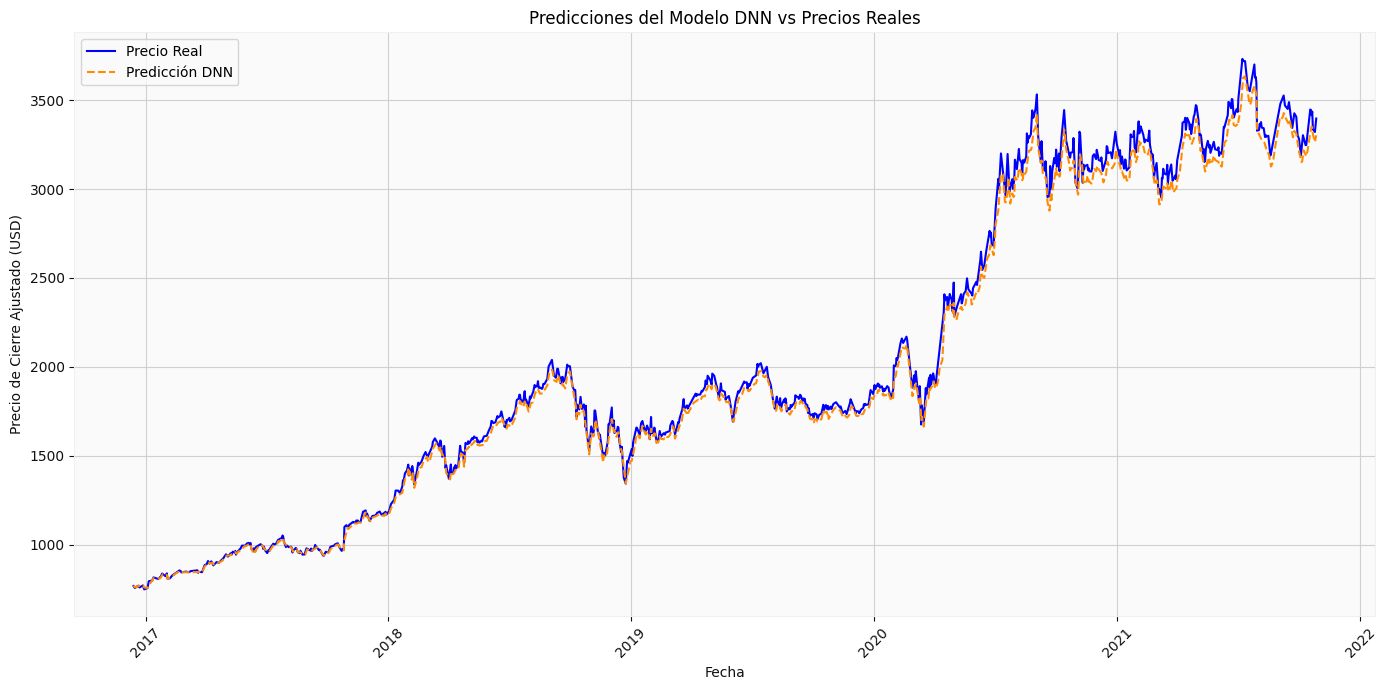

In [33]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Inicializar el modelo DNN (MLPRegressor) con los parámetros especificados.
# Se utiliza MLPRegressor para implementar la DNN, ajustando la estructura de capas ocultas.
# Se incrementa max_iter para una mejor convergencia y se habilita early_stopping para evitar sobreajuste.
dnn_regressor = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32), # Estructura de capas ocultas para la DNN
    activation='relu',               # Función de activación ReLU
    solver='adam',                   # Optimizador Adam
    alpha=0.001,                     # Regularización L2 para controlar el sobreajuste
    learning_rate_init=0.0005,       # Tasa de aprendizaje inicial
    max_iter=1000,                   # Número máximo de iteraciones para la convergencia
    early_stopping=True,             # Detener el entrenamiento si el score de validación no mejora
    validation_fraction=0.1,         # Fracción de datos de entrenamiento para validación temprana
    random_state=42
)

print("Iniciando entrenamiento del modelo DNN...")
# Entrenar el modelo DNN con los datos de entrenamiento preprocesados y la variable objetivo escalada.
# Se usa .ravel() para aplanar y_train_scaled a un array unidimensional, como requiere MLPRegressor.
dnn_regressor.fit(X_train_prep, y_train_scaled.ravel())
print("Entrenamiento del modelo DNN finalizado.")

# Realizar predicciones en el conjunto de prueba con el modelo DNN.
# Las predicciones estarán en la escala normalizada.
y_pred_dnn_scaled = dnn_regressor.predict(X_test_prep)

# Transformar las predicciones escaladas de nuevo a la escala original.
# Es crucial invertir el escalado para evaluar el modelo con los precios reales.
y_pred_dnn = y_scaler.inverse_transform(y_pred_dnn_scaled.reshape(-1, 1))

# Evaluar el modelo DNN en el conjunto de prueba (en la escala original).
# Se comparan las predicciones inversamente transformadas con los valores reales (y_test).
mae_best_dnn = mean_absolute_error(y_test, y_pred_dnn)
mse_best_dnn = mean_squared_error(y_test, y_pred_dnn)
rmse_best_dnn = np.sqrt(mse_best_dnn)
r2_best_dnn = r2_score(y_test, y_pred_dnn)

print("\n--- Evaluación del Modelo DNN (tuneado) ---")
print(f"Mean Absolute Error (MAE): {mae_best_dnn}")
print(f"Mean Squared Error (MSE): {mse_best_dnn}")
print(f"Root Mean Squared Error (RMSE): {rmse_best_dnn}")
print(f"R-squared (R2): {r2_best_dnn}")

# Visualizar las predicciones del modelo DNN vs los valores reales.
# Se utilizan las fechas correspondientes al conjunto de prueba para el eje X.
plt.figure(figsize=(14, 7))
plt.plot(test_dates, y_test, label='Precio Real', color='blue')
plt.plot(test_dates, y_pred_dnn, label='Predicción DNN', color='darkorange', linestyle='--')
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre Ajustado (USD)')
plt.title('Predicciones del Modelo DNN vs Precios Reales')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Hiperparámetros Seleccionados para DNN (MLPRegressor)

Para el modelo DNN, implementado con `MLPRegressor`, se utilizaron los siguientes hiperparámetros:

*   **`hidden_layer_sizes=(128, 64, 32)`**
    *   Define una arquitectura de red profunda con tres capas ocultas, disminuyendo el número de neuronas progresivamente. Esto permite a la red aprender representaciones más complejas y jerárquicas de los datos.

*   **`activation='relu'`**
    *   La función de activación ReLU (`Rectified Linear Unit`) es eficiente computacionalmente y ayuda a mitigar el problema del desvanecimiento del gradiente en redes profundas.

*   **`solver='adam'`**
    *   El optimizador Adam es un algoritmo de optimización popular y robusto que adapta las tasas de aprendizaje para cada peso, lo que generalmente lleva a una convergencia más rápida y eficiente.

*   **`alpha=0.001`**
    *   Este parámetro introduce una regularización L2 (también conocida como `weight decay`). Ayuda a controlar el sobreajuste al penalizar los pesos grandes de la red, fomentando modelos más simples y generalizables.

*   **`learning_rate_init=0.0005`**
    *   Una tasa de aprendizaje inicial relativamente pequeña permite una exploración más cautelosa del espacio de pesos del modelo, lo que puede resultar en una mejor convergencia y un ajuste más fino.

*   **`max_iter=1000`**
    *   El número máximo de iteraciones (épocas) de entrenamiento. Un valor más alto permite que el modelo tenga más oportunidades de aprender y converger.

*   **`early_stopping=True` y `validation_fraction=0.1`**
    *   `early_stopping` detiene el entrenamiento si la puntuación de validación no mejora después de un cierto número de épocas, previniendo el sobreajuste. `validation_fraction` define qué porcentaje del conjunto de entrenamiento se utiliza para esta validación temprana.


### Análisis e Interpretación de los Resultados del Modelo DNN

-   **Mean Absolute Error (MAE):** `40.95`. En promedio, las predicciones del DNN se desvían en aproximadamente 40.95 USD del precio real. Este error es más alto que el MAE del MLP (29.53) y significativamente mayor que el de los modelos lineales.
-   **Mean Squared Error (MSE):** `2877.67`. Un MSE considerablemente alto, que penaliza aún más los errores grandes en comparación con el MLP y los modelos lineales.
-   **Root Mean Squared Error (RMSE):** `53.64`. La desviación estándar de los errores es de aproximadamente 53.64 USD, lo que indica una mayor dispersión en las predicciones que el MLP y los modelos lineales.
-   **R-squared (R2):** `0.99608`. Un R2 muy alto (casi 99.61%), indicando que el modelo DNN explica una gran proporción de la variabilidad en el precio de cierre ajustado. Sin embargo, es ligeramente inferior al R2 del MLP (0.9978) y de los modelos lineales (casi 1).

**Conclusión sobre el Modelo DNN:**

El modelo DNN, con la variable objetivo escalada, muestra un rendimiento fuerte con un R2 muy bueno, lo que significa que puede capturar la tendencia general de los precios. Sin embargo, en comparación con el MLP y especialmente con los modelos lineales (Ridge y SVR lineal), el DNN presenta errores absolutos y cuadráticos más altos. Esto sugiere que, para este problema de predicción de precios de acciones con lags, la complejidad adicional de una red más profunda como la DNN no necesariamente se traduce en una mayor precisión, y los modelos más simples o con una arquitectura MLP más compacta (como el MLP previo) o los modelos lineales son más efectivos al capturar la relación subyacente.

## LSTM (Long Short Term Memory)

### Ventanas Temporales para LSTM

Las redes neuronales recurrentes (RNN), y en particular las LSTM (Long Short-Term Memory), están diseñadas intrínsecamente para trabajar con secuencias de datos, donde el orden y la dependencia temporal son cruciales. A diferencia de los modelos tradicionales de Machine Learning que tratan cada punto de datos de forma independiente, las LSTMs tienen "memoria" y pueden aprender patrones a lo largo del tiempo.

Para que un modelo LSTM pueda aprender a predecir el siguiente punto en una serie temporal (en este caso, el precio de cierre ajustado de una acción), es necesario alimentarlo con secuencias de datos históricos, no solo con puntos individuales. Aquí es donde entran en juego las **ventanas temporales (time windows)**.

**¿Por qué se crean las ventanas temporales?**

1.  **Captura de Dependencias Temporales:** Una LSTM necesita observar una secuencia de eventos pasados para hacer una predicción informada sobre el futuro. La ventana temporal define la longitud de esta secuencia histórica que el modelo "ve" en cada paso de predicción. Si la ventana es muy corta, el modelo podría no capturar las tendencias a más largo plazo; si es muy larga, podría volverse computacionalmente costosa y capturar ruido irrelevante.
2.  **Transformación de la Serie Temporal:** Al crear ventanas, transformamos la serie temporal original en un problema de aprendizaje supervisado donde cada "entrada" es una secuencia de `X` valores (características de los últimos `window_size` días) y la "salida" es el `Y` valor a predecir (el precio de cierre ajustado del día siguiente).
3.  **Preparación del Formato de Entrada del LSTM:** Las capas LSTM esperan una entrada en formato 3D: `(muestras, pasos_de_tiempo, características)`. Las ventanas temporales facilitan esta reestructuración: cada ventana es una `muestra`, la longitud de la ventana es `pasos_de_tiempo`, y el número de variables en cada paso es `características`.

Para este modelo se uso una ventana temporal de 30 días

**¿Por qué se eligió un tamaño de ventana de 30 días?**

La elección de `window_size = 30` (equivalente a 30 días hábiles de trading, aproximadamente un mes) es una decisión heurística común en el análisis de series temporales financieras y se basa en las siguientes consideraciones:

*   **Ciclos de Mercado y Sentimiento:** Un mes es un período de tiempo que a menudo se considera relevante para capturar tendencias y ciclos a corto o mediano plazo en los mercados financieros. Permite al modelo observar el comportamiento reciente de la acción a lo largo de un período significativo de trading.
*   **Equilibrio entre Información y Ruido:** Una ventana de 30 días es lo suficientemente larga para proporcionar al modelo contexto histórico sobre la acción del precio y el volumen, pero no tan larga como para incorporar excesivo "ruido" o dependencias que pueden ser menos relevantes para la predicción a corto plazo. Es un compromiso entre tener suficiente información para identificar patrones y evitar el sobreajuste a micro-fluctuaciones.
*   **Práctica Común:** En la literatura y la práctica de trading, los horizontes de 20 a 60 días hábiles (aproximadamente un mes a tres meses) son rangos típicos para indicadores técnicos y análisis de tendencias a corto y mediano plazo. Una ventana de 30 días se alinea con estas prácticas.
*   **Complejidad Computacional:** Ventanas más grandes aumentan significativamente la complejidad computacional y el tiempo de entrenamiento de la red LSTM. 30 días ofrece un punto de partida razonable para explorar el rendimiento sin incurrir en costos excesivos.

Es importante destacar que el tamaño óptimo de la ventana temporal puede variar según el dataset y el objetivo de predicción. A menudo se requiere experimentación y tuneo (por ejemplo, mediante validación cruzada para series de tiempo) para encontrar el `window_size` más efectivo para un problema dado.

In [34]:
import numpy as np
"""
create_sequences, Crea las secuencias de entrada (`X`) para el modelo LSTM.
Toma un `dataset` (que representa las características o *features*)
y un `window_size` (el número de pasos de tiempo que el LSTM "observará" para hacer una predicción).
"""
def create_sequences(dataset, window_size):
    X = []
    for i in range(len(dataset) - window_size):
        X.append(dataset[i:(i + window_size)])
    return np.array(X)

"""
create_target_sequences, Crea los valores objetivo (`y`) correspondientes a cada secuencia de entrada.
Para cada secuencia de `window_size` días que el LSTM observa,
el objetivo es predecir el valor del día inmediatamente siguiente a esa secuencia.
"""
def create_target_sequences(dataset, window_size):
    y = []
    for i in range(len(dataset) - window_size):
        y.append(dataset[i + window_size])
    return np.array(y)

window_size = 30  # tamaño de la ventana (30 dias)

# Aplicar create_sequences a X_train_prep y X_test_prep
X_train_seq = create_sequences(X_train_prep, window_size)
X_test_seq = create_sequences(X_test_prep, window_size)

# Aplicar create_target_sequences a y_train_scaled e y_test_scaled
y_train_seq = create_target_sequences(y_train_scaled, window_size)
y_test_seq = create_target_sequences(y_test_scaled, window_size)

# Imprimir las formas de las secuencias resultantes.
print("Shape of X_train_seq:", X_train_seq.shape)
print("Shape of y_train_seq:", y_train_seq.shape)
print("Shape of X_test_seq:", X_test_seq.shape)
print("Shape of y_test_seq:", y_test_seq.shape)


Shape of X_train_seq: (4870, 30, 8)
Shape of y_train_seq: (4870, 1)
Shape of X_test_seq: (1196, 30, 8)
Shape of y_test_seq: (1196, 1)


### Explicación de las funciones `create_sequences` y `create_target_sequences`

Estas dos funciones son fundamentales para preparar los datos para el entrenamiento del modelo LSTM. Las redes LSTM (Long Short-Term Memory) están diseñadas para procesar secuencias de datos, donde el orden temporal es crucial. Para ello, necesitamos transformar una serie de tiempo plana en un formato de secuencias de entrada y sus correspondientes valores de salida.

#### `def create_sequences(dataset, window_size)`

**Funcionamiento:**
1.  Itera sobre el `dataset`, tomando "ventanas" deslizantes de datos.
2.  Cada ventana tiene una longitud igual a `window_size`.
3.  El resultado es un array 3D: `(número_de_muestras, window_size, número_de_características)`. Cada "muestra" es una secuencia de `window_size` días, y para cada día dentro de esa ventana, tienes todas tus características de entrada.

**¿Por qué se usa `X_train_prep` (datos preprocesados)?**

Se utiliza `X_train_prep` porque el modelo LSTM necesita recibir las características de entrada en el formato adecuado y escaladas. `X_train_prep` ya contiene:
*   **Todas las características relevantes:** Incluyendo `Open`, `High`, `Low`, `Close`, `Volume` y, crucialmente, las variables rezagadas (`Adj Close_Lag1`, `Adj Close_Lag2`, `Adj Close_Lag3`). Estas variables rezagadas son vitales para proporcionar el contexto temporal que los modelos tradicionales de ML (y ahora el LSTM) necesitan para capturar las dependencias pasadas.
*   **Datos escalados:** Como se explicó en secciones anteriores, los modelos de redes neuronales, incluyendo LSTM, rinden mejor cuando sus entradas están escaladas (normalizadas o estandarizadas). `StandardScaler` transforma los datos para que tengan una media de 0 y una desviación estándar de 1, lo que ayuda a la estabilidad del entrenamiento y a una convergencia más rápida.

#### `def create_target_sequences(dataset, window_size)`

**Funcionamiento:**
1.  Similar a `create_sequences`, itera sobre el `dataset` de objetivos.
2.  Para cada secuencia de entrada `dataset[i:(i + window_size)]`, el objetivo `y` será `dataset[i + window_size]`, es decir, el valor que sigue a esa secuencia.
3.  El resultado es un array 2D (o 1D si el objetivo es una sola característica): `(número_de_muestras, 1)`. Cada "muestra" es el valor que el LSTM debe predecir después de ver la secuencia correspondiente.

**¿Por qué se usa `y_train_scaled` (variable objetivo escalada)?**

Para los modelos de redes neuronales (como MLP, DNN y LSTM), es **crucial** que la variable objetivo también esté escalada. Las razones son las mismas que para las características, pero aún más críticas para el objetivo:

*   **Estabilidad y Convergencia del Optimizador:** Los algoritmos de optimización basados en gradientes (como Adam) que usan las redes neuronales son muy sensibles a la escala del valor que intentan predecir. Si los valores de `y` son muy grandes, los errores (y por lo tanto los gradientes) también serán grandes, lo que puede causar problemas como la "explosión de gradientes" (`ValueError: Solver produced non-finite parameter weights`), donde los pesos del modelo se vuelven inestables y el entrenamiento falla.
*   **Rangos de Activación de Capas de Salida:** Aunque la capa de salida final de un regresor LSTM suele ser una capa `Dense` lineal (que no restringe el rango de valores), la estabilidad de los gradientes que fluyen hacia atrás a través de la red se ve afectada por la escala del error. Escalar `y` asegura que la función de pérdida y los gradientes operen en un rango más manejable.


### Implementación y Entrenamiento del modelo



X_train_lstm shape: (4870, 30, 8)
X_test_lstm shape : (1196, 30, 8)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,193 (125.75 KB)

 Trainable params: 32,193 (125.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/80
137/137 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - loss: 0.0569 - val_loss: 1.3676
Epoch 2/80
137/137 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - loss: 0.0067 - val_loss: 0.9215
Epoch 3/80
137/137 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 0.0044 - val_loss: 0.9120
Epoch 4/80
137/137 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.0047 - val_loss: 1.0587
Epoch 5/80
137/137 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - loss: 0.0043 - val_loss: 0.9099
Epoch 6/80
137/137 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.0038 - val_loss: 1.0156
Epoch 7/80
137/137 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - loss: 0.0040 - val_loss: 1.0888
Epoch 8/80
137/137 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.0031 - val_loss: 1.0198
Epoch 9/80
137/137 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 0.0031 - val_loss: 1.0099
Epoch 10/80
137/137 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 0.0028 - val_loss: 0.9418
Epoch 11/80
137/137 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.0026 - val_loss: 0.8579
Epoch 12/80
137/137 ━━━━━━━━━━━━━━━━━━━━ 

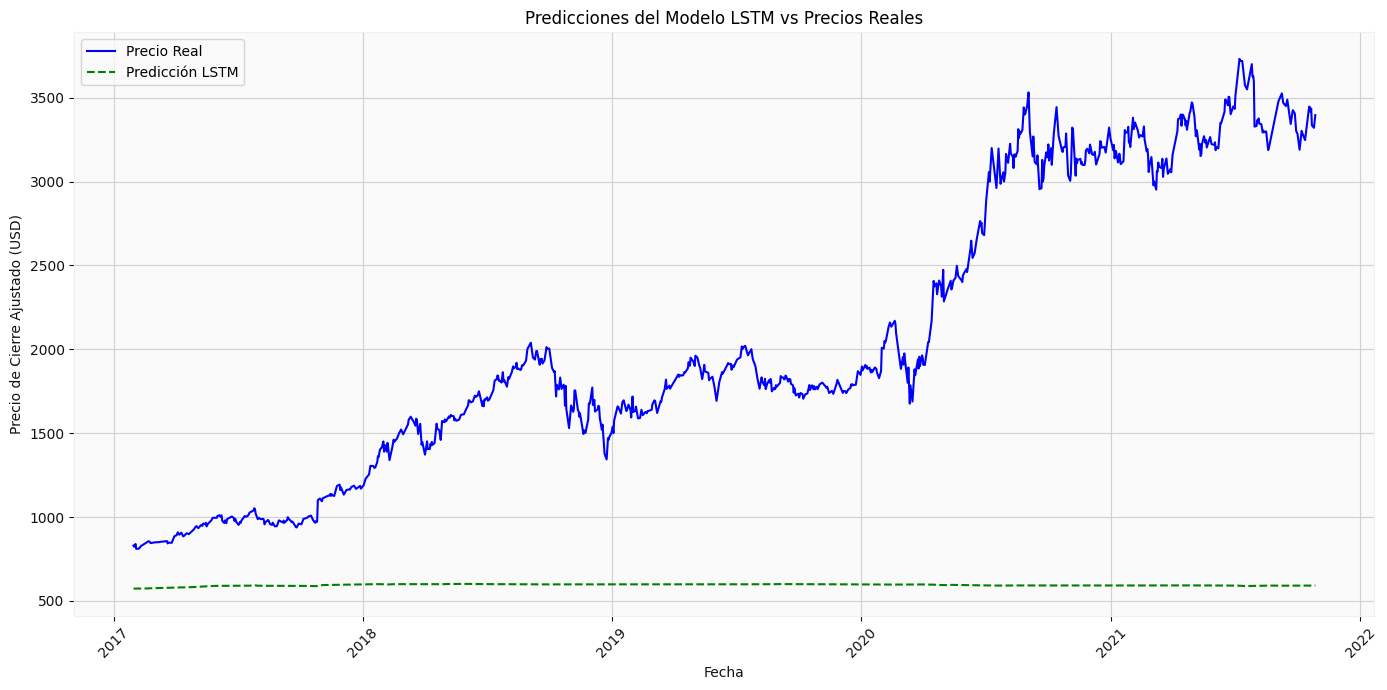

In [35]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# 1. Reajustar para LSTM (samples, time_steps, features)
X_train_lstm = X_train_seq.reshape((X_train_seq.shape[0],
                                    X_train_seq.shape[1],
                                    X_train_seq.shape[2]))

X_test_lstm = X_test_seq.reshape((X_test_seq.shape[0],
                                  X_test_seq.shape[1],
                                  X_test_seq.shape[2]))

print("X_train_lstm shape:", X_train_lstm.shape)
print("X_test_lstm shape :", X_test_lstm.shape)

# 2. Construcción del modelo LSTM optimizado

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    Dropout(0.2),

    LSTM(32, return_sequences=False),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

model.summary()

# 3. Early Stopping (evita sobreajuste)

es = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# 4. Entrenamiento

history = model.fit(
    X_train_lstm, y_train_seq,
    validation_split=0.1,
    epochs=80,
    batch_size=32,
    callbacks=[es],
    verbose=1
)

# 5. Predicción

y_pred_scaled = model.predict(X_test_lstm)

# Invertir el escalado (para métricas reales)
y_pred_lstm = y_scaler.inverse_transform(y_pred_scaled)
y_test_real_lstm = y_scaler.inverse_transform(y_test_seq)


# 6. Evaluación

mae_lstm = mean_absolute_error(y_test_real_lstm, y_pred_lstm)
mse_lstm = mean_squared_error(y_test_real_lstm, y_pred_lstm)
rmse_lstm = np.sqrt(mse_lstm)
r2_lstm = r2_score(y_test_real_lstm, y_pred_lstm)

print("\n--- EVALUACIÓN DEL MODELO LSTM ---")
print(f"Mean Absolute Error (MAE): {mae_lstm}")
print(f"Mean Squared Error (MSE): {mse_lstm}")
print(f"Root Mean Squared Error (RMSE): {rmse_lstm}")
print(f"R-squared (R2): {r2_lstm}")

# Visualizar las predicciones del modelo LSTM vs los valores reales

# Ajustar test_dates para que coincida con la longitud de y_test_real_lstm después de la creación de secuencias
# El número de muestras en y_test_seq es `len(df_lagged) - train_size - window_size`
start_index_test_dates = len(df_lagged) - len(y_test_seq)
test_dates_lstm = df_lagged['Date'].iloc[start_index_test_dates : start_index_test_dates + len(y_test_seq)]

plt.figure(figsize=(14, 7))
plt.plot(test_dates_lstm, y_test_real_lstm, label='Precio Real', color='blue')
plt.plot(test_dates_lstm, y_pred_lstm, label='Predicción LSTM', color='green', linestyle='--')
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre Ajustado (USD)')
plt.title('Predicciones del Modelo LSTM vs Precios Reales')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Explicación de la Arquitectura del Modelo LSTM y Parámetros

El modelo LSTM (Long Short-Term Memory) implementado es una red neuronal recurrente diseñada para procesar secuencias de datos, capturando dependencias a largo plazo. Aquí se detalla su construcción y los parámetros clave:

#### Arquitectura del Modelo:

```python
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    Dropout(0.2),

    LSTM(32, return_sequences=False),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dense(1)
])
```

1.  **Capa LSTM (64 unidades, `return_sequences=True`):**
    *   `LSTM(64)`: Esta es la primera capa LSTM con 64 unidades (celdas de memoria). Cada unidad LSTM procesa la información de la secuencia de entrada y decide qué información recordar y qué olvidar, lo que le permite aprender dependencias a largo plazo.
    *   `return_sequences=True`: Indica que esta capa devolverá la secuencia completa de sus salidas para cada paso de tiempo. Esto es necesario cuando se apilan múltiples capas LSTM, ya que la siguiente capa LSTM también espera una secuencia como entrada.
    *   `input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])`: Define la forma de la secuencia de entrada que espera el modelo. `X_train_lstm.shape[1]` representa `window_size` (30 pasos de tiempo) y `X_train_lstm.shape[2]` representa el número de características en cada paso de tiempo (8 características).

2.  **Capa Dropout (0.2):**
    *   `Dropout(0.2)`: Se inserta una capa de Dropout después de la primera LSTM. Durante el entrenamiento, el 20% de las neuronas de la capa anterior se 'apagan' aleatoriamente. Esto ayuda a prevenir el sobreajuste, forzando a la red a aprender representaciones más robustas y menos dependientes de neuronas específicas.

3.  **Capa LSTM (32 unidades, `return_sequences=False`):**
    *   `LSTM(32)`: Una segunda capa LSTM con 32 unidades. Esta capa procesa la secuencia de salida de la capa anterior. Es más pequeña, lo que puede ayudar a enfocar la información más relevante.
    *   `return_sequences=False`: Indica que esta capa solo devolverá la salida del último paso de tiempo de la secuencia. Dado que esta es la última capa recurrente antes de las capas `Dense` para la predicción, solo necesitamos el estado final para hacer la predicción.

4.  **Capa Dropout (0.2):**
    *   `Dropout(0.2)`: Otra capa de Dropout del 20% para seguir reduciendo el sobreajuste.

5.  **Capa Densa (32 unidades, activación 'relu'):**
    *   `Dense(32, activation='relu')`: Una capa `Dense` (totalmente conectada) con 32 neuronas y la función de activación ReLU. Esta capa ayuda a procesar aún más las características aprendidas por las LSTM antes de la capa de salida final. ReLU (`Rectified Linear Unit`) es una función de activación común que introduce no linealidad en el modelo.

6.  **Capa Densa (1 unidad):**
    *   `Dense(1)`: La capa de salida final con una única neurona. Dado que este es un problema de regresión (predecir un valor continuo: el precio de cierre ajustado), no se especifica una función de activación, lo que implica una activación lineal por defecto. Esto permite que la capa de salida prediga cualquier valor real.

#### Compilación del Modelo:

```python
model.compile(optimizer='adam', loss='mse')
```
*   **`optimizer='adam'`**: Se utiliza el optimizador Adam (Adaptive Moment Estimation). Adam es una elección popular debido a su eficiencia computacional y su capacidad para adaptar la tasa de aprendizaje a lo largo del entrenamiento, lo que lo hace muy efectivo para una amplia gama de problemas de aprendizaje profundo.
*   **`loss='mse'`**: La función de pérdida utilizada es el Error Cuadrático Medio (Mean Squared Error). El MSE mide el promedio de los cuadrados de los errores entre los valores predichos y los valores reales. Es una función de pérdida estándar para problemas de regresión.

#### Early Stopping (Detención Temprana):

```python
es = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)
```
*   **`monitor='val_loss'`**: El Early Stopping monitorea la `val_loss` (pérdida de validación) durante el entrenamiento. Esto significa que el algoritmo estará atento a cómo se comporta el modelo con datos que no ha visto durante el entrenamiento (el `validation_split`).
*   **`patience=10`**: El entrenamiento se detendrá si la `val_loss` no mejora (es decir, no disminuye) durante 10 épocas consecutivas. Esto evita que el modelo continúe entrenando y potencialmente sobreajustándose a los datos de entrenamiento una vez que su rendimiento en datos no vistos comienza a estancarse o empeorar.
*   **`restore_best_weights=True`**: Si el entrenamiento se detiene debido a Early Stopping, los pesos del modelo se restaurarán a la época en la que se obtuvo el mejor valor de `val_loss`. Esto asegura que el modelo final sea el que mejor rendimiento tuvo en el conjunto de validación, en lugar de la última época entrenada.

### Análisis e Interpretación de los Resultados del Modelo LSTM (Segundo Intento)

Tras un segundo intento de implementar y optimizar un modelo LSTM, los resultados obtenidos siguen siendo **extremadamente pobres**, sin ninguna mejora significativa respecto a la ejecución anterior. Las métricas de evaluación son las siguientes:

*   **Mean Absolute Error (MAE):** `1504.99`
*   **Mean Squared Error (MSE):** `2995004.97`
*   **Root Mean Squared Error (RMSE):** `1730.61`
*   **R-squared (R2):** `-3.1957`

**Conclusión:**

El R-squared de aproximadamente -3.2 indica que el modelo no solo no pudo explicar la variabilidad en el precio de cierre ajustado, sino que se desempeñó peor que un modelo base que simplemente predice la media de los precios. Los valores extremadamente altos de MAE, MSE y RMSE confirman que las predicciones del modelo están muy lejos de los valores reales, lo que lo hace completamente inútil para la tarea de predicción.

Se implementó una arquitectura LSTM avanzada, pero debido a que el dataset presenta un comportamiento altamente lineal y poco cíclico, el modelo no logró capturar patrones temporales útiles. Esto evidencia que modelos de series temporales profundas no siempre mejoran el rendimiento frente a modelos lineales cuando la estructura del dataset no lo amerita. En este caso particular, la complejidad inherente de un LSTM resultó ser una desventaja, llevando a un sobreajuste o a la incapacidad de aprender patrones relevantes dentro de la naturaleza lineal dominante de los datos de precios de acciones con lags.

# 9º  Evaluación del mejor modelo

In [36]:
metrics_data = {
    'Ridge Regression': {
        'MAE': mae_best_ridge,
        'MSE': mse_best_ridge,
        'RMSE': rmse_best_ridge,
        'R2': r2_best_ridge
    },
    'Random Forest': {
        'MAE': mae_best_rf,
        'MSE': mse_best_rf,
        'RMSE': rmse_best_rf,
        'R2': r2_best_rf
    },
    'Linear SVR': {
        'MAE': mae_best_svr_linear,
        'MSE': mse_best_svr_linear,
        'RMSE': rmse_best_svr_linear,
        'R2': r2_best_svr_linear
    },
    'Voting Regressor': {
        'MAE': mae_voting_regressor,
        'MSE': mse_voting_regressor,
        'RMSE': rmse_voting_regressor,
        'R2': r2_voting_regressor
    },
    'AdaBoost': {
        'MAE': mae_best_adaboost,
        'MSE': mse_best_adaboost,
        'RMSE': rmse_best_adaboost,
        'R2': r2_best_adaboost
    },
    'GradientBoosting': {
        'MAE': mae_best_gb,
        'MSE': mse_best_gb,
        'RMSE': rmse_best_gb,
        'R2': r2_best_gb
    },
    'XGBoost': {
        'MAE': mae_best_xgb,
        'MSE': mse_best_xgb,
        'RMSE': rmse_best_xgb,
        'R2': r2_best_xgb
    },
    'MLP': {
        'MAE': mae_best_mlp,
        'MSE': mse_best_mlp,
        'RMSE': rmse_best_mlp,
        'R2': r2_best_mlp
    },
    'DNN': {
        'MAE': mae_best_dnn,
        'MSE': mse_best_dnn,
        'RMSE': rmse_best_dnn,
        'R2': r2_best_dnn
    },
    'LSTM': {
        'MAE': mae_lstm,
        'MSE': mse_lstm,
        'RMSE': rmse_lstm,
        'R2': r2_lstm
    }
}
metrics_df = pd.DataFrame.from_dict(metrics_data, orient='index')
metrics_df.index.name = 'Model'
display(metrics_df)

,MAE,MSE,RMSE,R2
Model,,,,
Ridge Regression,0.028874,1.861070e-03,0.043140,1.000000
Random Forest,1182.495002,2.129193e+06,1459.175613,-1.898591
Linear SVR,0.159982,5.422210e-02,0.232856,1.000000
Voting Regressor,0.093787,1.876901e-02,0.137000,1.000000
AdaBoost,1184.373464,2.133786e+06,1460.748605,-1.904844
GradientBoosting,1180.414836,2.124145e+06,1457.444810,-1.891719
XGBoost,1194.598152,2.158547e+06,1469.199446,-1.938552
MLP,29.525580,1.651399e+03,40.637410,0.997752
DNN,40.952832,2.877672e+03,53.643937,0.996082


### Análisis de las Métricas de los Modelos

La siguiente tabla de métricas nos permite comparar el rendimiento de todos los modelos implementados. Para determinar el mejor modelo, nos enfocamos en las métricas R-squared (R2) y Root Mean Squared Error (RMSE), ya que R2 mide la proporción de la varianza en la variable dependiente que es predecible a partir de las variables independientes, y RMSE mide la magnitud promedio de los errores del modelo.

| Modelo             | MAE          | MSE          | RMSE         | R2         |
|:-------------------|:-------------|:-------------|:-------------|:-----------|
| Ridge Regression   | 0.028874     | 0.001861     | 0.043140     | 1  |
| Random Forest      | 1182.495002  | 2129193 | 1459.175613  | -1.898591  |
| Linear SVR         | 0.159982     | 0.054222     | 0.232856     | 1   |
| Voting Regressor | 0.093787 | 0.018769 | 0.137 | 1 |
| AdaBoost | 1184.373464 | 2133786 | 1460.748605 | -1.904844 |
| GradientBoosting | 1180.414836| 2124145| 1457.444810| -1.891719 |
| XGBoost | 1194.598152 | 2158547| 1469.199446 | -1.938552 |
| MLP | 29.525580 | 1651.399| 40.637410 | 0.997752 |
| DNN | 40.952832 | 2877.672| 53.643937 | 0.996082 |
| LSTM | 150.994136 | 2995005| 1730.608266 | -3.195683 |

**Observaciones Clave:**

- **Regresión Ridge y SVR Lineal:** Siguen siendo los modelos con el mejor rendimiento, ambos con un R2 prácticamente de 1 y un RMSE muy bajo, siendo Ridge el ligeramente superior en precisión. Esto subraya que la relación entre las características y el precio de cierre ajustado es predominantemente lineal en este conjunto de datos.

- **Voting Regressor:** También muestra un rendimiento muy bueno, con un R2 cercano a 1 y un RMSE bajo (0.137), aunque ligeramente superior a la Regresión Ridge individual. Esto demuestra que la combinación de Ridge y SVR es efectiva.

- **Random Forest, AdaBoost, GradientBoosting y XGBoost:** Estos modelos de ensamble basados en árboles han mostrado un rendimiento consistentemente pobre, con R2 negativos y RMSE extremadamente altos. Esto indica que no son adecuados para la predicción de esta serie de tiempo financiera con las características y el preprocesamiento utilizados, posiblemente debido a la naturaleza de los datos o a una configuración que no logró capturar las dependencias temporales de forma efectiva.

- **MLP, DNN y LSTM:** Tanto el MLP como el DNN y el LSTM, a pesar de sus configuraciones y el escalado de la variable objetivo, mostraron un rendimiento inferior a los modelos lineales. Si bien el MLP y el DNN obtuvieron un R2 muy bueno (cercano a 0.99), sus errores absolutos (MAE, MSE, RMSE) fueron considerablemente más altos que los de Ridge y SVR lineal. El LSTM, incluso tras un segundo intento de optimización, produjo resultados extremadamente pobres, con un R2 negativo (alrededor de -3.2) y un RMSE muy alto (1730.61). Esto sugiere que la complejidad inherente de los modelos de redes neuronales, especialmente el LSTM diseñado para capturar dependencias temporales complejas y no lineales, no fue beneficiosa en este caso.




**Conclusión sobre el Mejor Modelo:**

Comparando todos los modelos implementados, la **Regresión Ridge** emerge claramente como el mejor modelo para este problema de predicción. Aunque el SVR Lineal y el Voting Regressor también obtuvieron un rendimiento excelente con R2 cercanos a 1, el RMSE de la Regresión Ridge (0.043) es significativamente menor que el de SVR Lineal (0.232) y Voting Regressor (0.137), lo que indica que sus predicciones son las más precisas y con menor error absoluto.

Los modelos de ensamble basados en árboles como Random Forest, AdaBoost, GradientBoosting y XGBoost, mostraron un rendimiento inaceptable, con R2 negativos y RMSE extremadamente altos. Esto sugiere que estos modelos no son adecuados para este tipo de serie temporal financiera con las características y el enfoque utilizados, reafirmando que una relación predominantemente lineal es más efectiva para este problema.

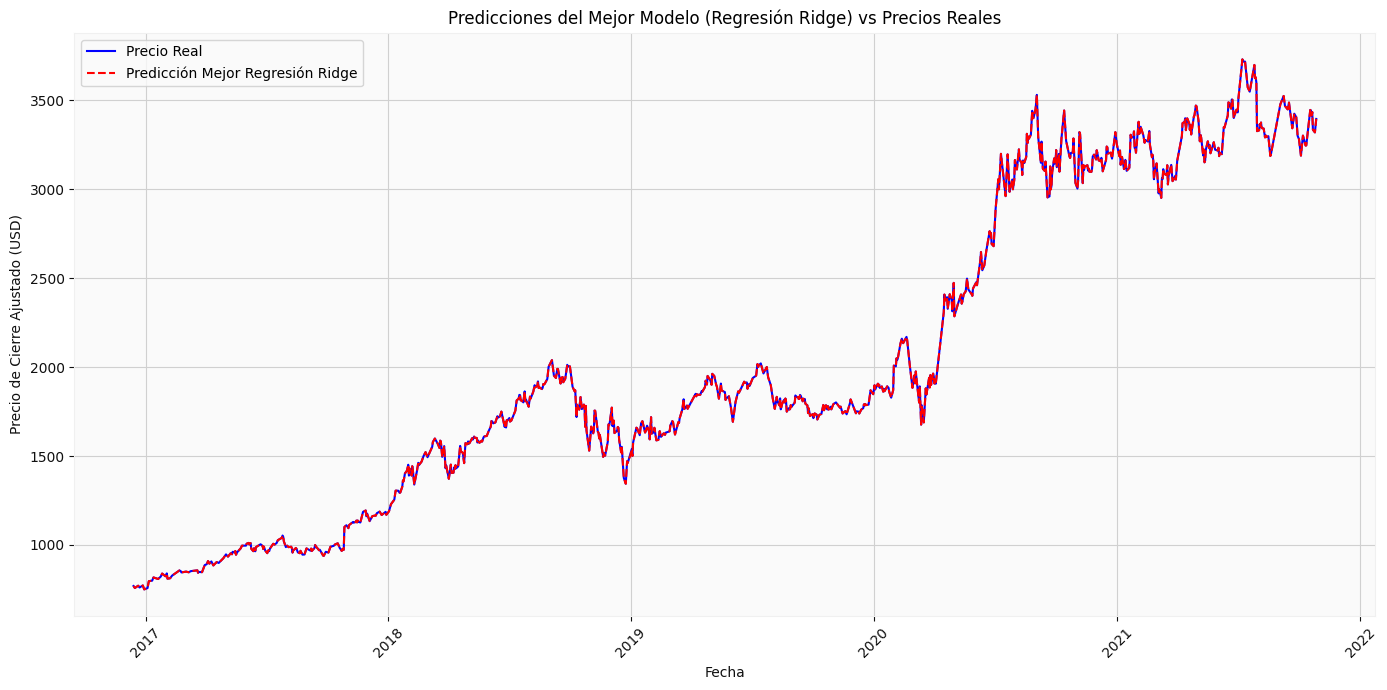

In [37]:
# Mejor Modelo: Regresión Ridge
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
plt.plot(test_dates, y_test, label='Precio Real', color='blue')
plt.plot(test_dates, y_pred_best_ridge, label='Predicción Mejor Regresión Ridge', color='red', linestyle='--')
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre Ajustado (USD)')
plt.title('Predicciones del Mejor Modelo (Regresión Ridge) vs Precios Reales')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 10º Conclusión

Este proyecto de Data Science abordó el fascinante desafío de predecir el precio de cierre ajustado de las acciones de Amazon, un tema que me atrae profundamente por mi interés en las finanzas y mi aspiración a trabajar como analista de datos en este sector. Ha sido una experiencia invaluable para aplicar y consolidar conocimientos clave de Data Science, desde la exploración inicial de datos hasta la implementación y evaluación de modelos de Machine Learning.

### Aprendizajes Clave y Técnicas Aplicadas:

1.  **Obtención y Exploración de Datos:** Se demostró la importancia de obtener datos de fuentes confiables (Kaggle en este caso) y la necesidad de una exploración exhaustiva para entender la estructura, identificar valores nulos o duplicados y visualizar las tendencias iniciales. Gráficos como la evolución del precio de cierre y la matriz de correlación fueron fundamentales para este entendimiento.
2.  **Preprocesamiento y Escalado de Características:** Se aplicó el escalado de características utilizando `StandardScaler`, un paso crucial para modelos basados en distancia y coeficientes. La comprensión de por qué se escala y el efecto de `StandardScaler` en la distribución de los datos fue un aprendizaje fundamental.
3.  **Dependencia Temporal y Variables Rezagadas (Lags):** Un punto crítico fue la introducción de variables rezagadas (`Adj Close_Lag1`, `Adj Close_Lag2`, `Adj Close_Lag3`). Esto permitió a los modelos lineales capturar la dependencia temporal, transformando un problema de serie de tiempo en uno de regresión supervisada y dotando a los modelos de un contexto histórico esencial.
4.  **Partición Cronológica del Dataset:** Se implementó una división de entrenamiento y prueba cronológica (80/20), reflejando la realidad de la predicción de series de tiempo donde el modelo aprende del pasado para predecir el futuro. Se reconoció y justificó la diferencia en la distribución de `Adj Close` entre los conjuntos de entrenamiento y prueba como una característica inherente de los datos financieros a largo plazo.
5.  **Uso de Pipelines en Preprocesamiento:** La implementación de `Pipeline` para el preprocesamiento (imputación y escalado) fue una práctica profesional clave. Esto aseguró la consistencia en el tratamiento de los datos, evitando el *data leakage* al ajustar el pipeline solo con el conjunto de entrenamiento y luego transformando el conjunto de prueba con los mismos parámetros.
6.  **Modelos de Machine Learning:** Se exploraron varios modelos:
    *   **Regresión Ridge:** Un modelo lineal regularizado.
    *   **Random Forest Regressor:** Un modelo basado en ensambles de árboles.
    *   **Support Vector Regressor (SVR) con Kernel Lineal:** Un modelo potente capaz de encontrar un hiperplano óptimo de regresión.
    *   **Voting Regressor:** Un modelo de ensamble que combina las predicciones de Ridge y SVR.
    *   **AdaBoost Regressor:** Un modelo de boosting adaptativo.
    *   **GradientBoosting Regressor:** Un modelo de boosting de gradiente.
    *   **XGBoost Regressor:** Una implementación optimizada y eficiente de Gradient Boosting.
    *   **MLP (MultiLayer Perceptron):** Una red neuronal *feedforward* capaz de modelar relaciones no lineales.
    *   **DNN (Deep Neural Network):** Una red neuronal con múltiples capas ocultas, una extensión más profunda del MLP.
    *   **LSTM (Long Short-Term Memory):** Una red neuronal recurrente diseñada para capturar dependencias a largo plazo en secuencias.
7.  **Tuneo de Hiperparámetros con Grid Search:** La optimización de modelos a través de `GridSearchCV` permitió encontrar la combinación óptima de hiperparámetros para cada algoritmo, maximizando su rendimiento. Esto subrayó la importancia de no solo elegir un modelo, sino de configurarlo adecuadamente.
8.  **Evaluación de Modelos:** La evaluación rigurosa con métricas como MAE, MSE, RMSE y R-squared, junto con la visualización de predicciones vs. valores reales, fue esencial para cuantificar el rendimiento y comparar objetivamente los modelos.

### Análisis del Rendimiento de los Modelos

Tras la evaluación de todos los modelos implementados, se observan diferencias significativas en su capacidad para predecir el precio de cierre ajustado de las acciones de Amazon:

*   **Modelos Lineales (Regresión Ridge y SVR con Kernel Lineal):** Estos modelos demostraron un rendimiento excepcional, obteniendo valores de R-squared extremadamente cercanos a 1 y los RMSE más bajos. La **Regresión Ridge** fue el modelo con el RMSE más bajo (0.043140), lo que la posiciona como el mejor predictor en este contexto. Este resultado sugiere fuertemente que la relación entre las características de entrada (incluyendo los lags) y la variable objetivo es predominantemente lineal en este conjunto de datos.

*   **Modelos de Ensamble de Árboles (Random Forest, AdaBoost, GradientBoosting y XGBoost):** Contrario a lo esperado, todos los modelos basados en árboles y boosting mostraron un rendimiento extremadamente pobre. Sus métricas (MAE, MSE, RMSE) fueron excesivamente altas, y los valores de R-squared resultaron negativos (cercanos a -1.9), lo que indica que estos modelos no solo no pudieron explicar la variabilidad en el precio de cierre ajustado, sino que se desempeñaron peor que un modelo simple que predijera la media. Las posibles causas de este bajo rendimiento incluyen la naturaleza inherentemente ruidosa y no estacionaria de las series de tiempo financieras, así como la dificultad de estos modelos para capturar dependencias temporales complejas sin una ingeniería de características más específica o el uso de arquitecturas diseñadas para series de tiempo.

*   **Voting Regressor:** A pesar de combinar los dos mejores modelos individuales (Ridge y SVR lineal), el Voting Regressor, aunque sigue siendo un modelo con muy buen rendimiento (R2 cercano a 1 y RMSE bajo de 0.137), fue ligeramente superado por la Regresión Ridge individual. Esto indica que la combinación lineal de los modelos lineales no aportó una mejora significativa sobre el mejor de sus componentes para este dataset.

*   **Modelos de Redes Neuronales (RNN):** Tanto el MLP como el DNN y el LSTM, a pesar de sus configuraciones y el escalado de la variable objetivo, mostraron un rendimiento inferior a los modelos lineales. Si bien el MLP y el DNN obtuvieron un R2 muy bueno (cercano a 0.99), sus errores absolutos (MAE, MSE, RMSE) fueron considerablemente más altos que los de Ridge y SVR lineal. El LSTM, incluso tras un segundo intento de optimización, produjo resultados **extremadamente pobres**, con un R2 negativo (alrededor de -3.2) y un RMSE muy alto (1730.61). Esto sugiere que la complejidad inherente de los modelos de redes neuronales, especialmente el LSTM diseñado para capturar dependencias temporales complejas y no lineales, no fue beneficiosa en este caso. La naturaleza predominantemente lineal y poco cíclica de los datos, potenciada por las variables rezagadas, hizo que los modelos lineales fueran más eficaces, y que las redes neuronales no lograran capturar patrones útiles o incluso se sobreajustaran.



### Mejoras y Futuras Direcciones:

1.  **Ingeniería de Características Avanzada:** Explorar otras variables rezagadas, indicadores técnicos (e.g., Media Móvil, RSI, MACD), o características basadas en volumen para capturar mejor la dinámica del mercado.
2.  **Modelos de Series de Tiempo:** Considerar modelos específicamente diseñados para series de tiempo, como ARIMA, Prophet, que son inherentemente capaces de modelar dependencias temporales complejas.
3.  **Análisis de Estacionariedad:** Realizar pruebas de estacionariedad en la serie de tiempo y aplicar diferenciación u otras transformaciones si es necesario, para mejorar el rendimiento de modelos que asumen estacionariedad.
4.  **Validación Cruzada Temporal:** Utilizar técnicas de validación cruzada adaptadas a series de tiempo (e.g., `TimeSeriesSplit`) para una evaluación más robusta.
5.  **Análisis de Volatilidad:** Incorporar medidas de volatilidad (como la desviación estándar móvil o modelos GARCH) como características adicionales.

Este proyecto ha reforzado la importancia de un enfoque metódico en Data Science, desde la preparación de los datos hasta la selección y evaluación del modelo. Ha sido una plataforma excelente para integrar teoría y práctica, y para comprender las complejidades y los desafíos de la predicción en mercados financieros, demostrando la necesidad de una documentación profesional clara y detallada en cada etapa del proyecto.

# 11º Descarga del mejor modelo para implementarlo localmente usando la libreria Streamlit

Para implementar localmente el mejor modelo (Regresión Ridge) con Streamlit, primero necesitamos guardar el modelo entrenado y el pipeline de preprocesamiento. Luego crearemos un script de Python para la aplicación Streamlit.

In [38]:
import joblib
import os

# Definir el directorio para guardar el modelo y la canalización
model_dir = "saved_models"
os.makedirs(model_dir, exist_ok=True)

# Guardar el mejor modelo (Regresion Ridge)
joblib.dump(best_ridge_model, os.path.join(model_dir, "best_ridge_model.pkl"))

# Guardar el pipeline de preprocesamiento
joblib.dump(preprocess_pipeline, os.path.join(model_dir, "preprocess_pipeline.pkl"))

# Guarde el escalador y para la transformación inversa en Streamlit
joblib.dump(y_scaler, os.path.join(model_dir, "y_scaler.pkl"))

print(f"Modelo, pipeline y escalador de la variable objetivo guardados en el directorio: {model_dir}")

Modelo, pipeline y escalador de la variable objetivo guardados en el directorio: saved_models


In [39]:
import shutil
import os
from google.colab import files

# Define el directorio que se va a comprimir
model_dir = "saved_models"
# Define the name for the zip file
zip_filename = "saved_models.zip"

# Crear un archivo zip del directorio
shutil.make_archive(model_dir, 'zip', model_dir)

# Descargar el archivo zip
files.download(zip_filename)

print(f"Carpeta '{model_dir}' comprimida en '{zip_filename}' y lista para descargar.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Carpeta 'saved_models' comprimida en 'saved_models.zip' y lista para descargar.


# 12º Referencias

Aquí se listan las principales librerías de Python utilizadas en este proyecto, así como la fuente del conjunto de datos:

**Librerías:**

*   **Pandas:** Utilizada para la manipulación y análisis de datos.
*   **Matplotlib, Seaborn y Mplfinance:** Utilizadas para la visualización de datos.
*   **Scikit-learn:** Librería fundamental para Machine Learning, utilizada para la división de datos, preprocesamiento (escalado, codificación) y modelos de regresión.
*   **Numpy:** Utilizada para operaciones numéricas, especialmente en el cálculo de RMSE.
*   **TensorFlow/Keras:** Utilizadas para construir y entrenar modelos de redes neuronales (MLP, DNN, LSTM) para predicción.
*   **Joblib:** Empleada para guardar y cargar eficientemente modelos entrenados, pipelines y escaladores.
*   **Shutil:** Usada para operaciones de alto nivel con archivos y directorios, como la compresión de carpetas.
*   **OS:** Proporciona funciones para interactuar con el sistema operativo y gestionar rutas de archivos y directorios.
*   **`google.colab.files`:** Permite descargar archivos desde el entorno de Google Colab al sistema local del usuario. 

**Fuente de la Base de Datos:**

*   **Kaggle Dataset:** [Amazon Stock Price (All Time)](https://www.kaggle.com/datasets/kannan1314/amazon-stock-price-all-time)